# Tarea 2 — Patricio Sepúlveda Ewert

## Pregunta 1 — Carga, exploración y limpieza

**Dataset original.** 12.040 observaciones × 41 variables; panel balanceado de 86 ciudades × 140 semanas (Feb 2020 – Oct 2022) en 5 países (DE, ES, FR, IT, SE). 33 variables numéricas y 5 identificadores.

**Hallazgo crítico de calidad de datos.** Las cinco variables de política (`Valor_Stringency_Index`, `Valor_GovernmentResponseIndex`, `Valor_EconomicSupportIndex`, `Valor_Containment_Health_index` y `workplace_closing`) son idénticamente cero para todas las observaciones alemanas (5.460 obs). Mantenerlas contaminaría el regresor de interés con un cero artificial.

**Decisiones de limpieza:**

1. **Eliminación de Alemania**: por el problema descrito arriba.
2. **Eliminación de `edu2` y `edu3`**: 100 % faltantes en DE, sin información tras filtrar.
3. **Eliminación de `d1`–`d6`**: no documentadas en el diccionario; activas únicamente en ES y SE durante 2021-2022, con estructura anidada que sugiere hitos secuenciales país-específicos (probablemente fases de vacunación o reapertura) sin metadata para interpretarlas. Sus correlaciones con las variables de política documentadas son triviales (|ρ| ≤ 0.08). Incluirlas equivaldría a interacciones país × ventana temporal sin interpretación posible.
4. **Conversión a panel**: índice multinivel `(NAME, date)`.

**Panel final:** 6.580 obs × 47 ciudades × 140 semanas en 4 países (ES = 16, FR = 15, IT = 14, SE = 2).

**Variable dependiente:** `workplaces_raw` (variación porcentual de movilidad laboral vs. línea base pre-COVID). Media ≈ –27.4 p.p., rango ≈ [–87, +7]. Se prefiere sobre `workplaces` (versión "procesada") porque interesa el cambio total observado, no el residuo tras remover una tendencia que ya incluye parte del efecto pandémico.

**Tratamiento principal:** `Valor_Stringency_Index` ∈ [0, 100], índice de Oxford de severidad de las restricciones.

**Implicación estructural clave.** Las cinco variables de política varían a nivel **país-tiempo**, no ciudad-tiempo. Esto implica que:

1. La identificación del efecto provendrá de la variación temporal dentro de país, no de variación entre ciudades.
2. Los promedios por ciudad de stringency son perfectamente colineales con dummies de país (relevante para CRE en P6).
3. Los errores estándar requieren **clustering two-way (ciudad y tiempo)** para reflejar dependencia intra-país.

---

## Pregunta 2 — Pooled OLS

**Especificación:**
$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + u_{it}$$

con errores estándar two-way clusterizados (ciudad y tiempo).

### Estrategia de selección de variables (común a P2, P3 y P4)

El enunciado solicita estimar "la misma relación" en los tres modelos. Para honrar literalmente esta restricción y garantizar comparación apples-to-apples, **la selección backward se realiza UNA SOLA VEZ** sobre el Pooled OLS (modelo más permisivo, admite todas las variables incluidas las invariantes), y el conjunto resultante se aplica idénticamente a RE y FE. El FE absorbe mecánicamente las invariantes en $\alpha_i$ pero conserva el mismo set de regresores time-varying.

El conjunto inicial es **teóricamente motivado** (no kitchen sink): policy + carga epidemiológica + escala urbana + composición sectorial + demografía + dummies de país y año. Backward con umbral $p > 0.05$, manteniendo siempre `Valor_Stringency_Index` (regresor de interés).

### Modelo final (7 variables, R² = 0.355)

| Variable | β | SE | Interpretación |
|---|---|---|---|
| `Valor_Stringency_Index` | **–0.4005**\*\*\* | 0.054 | +1 punto Stringency → –0.40 p.p. de movilidad |
| `daily_cases` | **+0.0006**\*\*\* | 0.0002 | +1.000 casos/día → +0.6 p.p. (efecto pequeño) |
| `log_pop` | **–3.57**\*\*\* | 0.51 | ciudades grandes con menor movilidad |
| `country_FR` | **–6.02**\*\*\* | 1.15 | menor movilidad media vs España |
| `country_IT` | **+3.07**\*\*\* | 1.03 | mayor movilidad media vs España |
| `country_SE` | **–9.63**\*\*\* | 2.63 | menor movilidad media vs España |
| `year_2021` | **+5.27**\*\*\* | 1.90 | recuperación 2021 vs 2020 |

**Limitación estructural.** El Pooled OLS asume $E[u_{it}\mid X_{it}, Z_i] = 0$. Características no observadas (cultura local, densidad efectiva, capital social) están plausiblemente correlacionadas con la severidad política y sesgan $\hat\beta_1$.

---

## Pregunta 3 — Efectos Fijos (within estimator)

**Especificación:**
$$\text{workplaces\_raw}_{it} = \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + \alpha_i + u_{it}$$

Estimación por transformación within; SE two-way clusterizados.

**Variables:** exactamente las mismas time-varying que sobrevivieron al backward del Pooled (Stringency, daily_cases, year_2021). Las invariantes (log_pop, dummies de país) son absorbidas mecánicamente por $\alpha_i$ — característica del estimador within, no decisión metodológica.

### Modelo final (R² within = 0.322)

| Variable | β | SE | Interpretación |
|---|---|---|---|
| `Valor_Stringency_Index` | **–0.4008**\*\*\* | 0.054 | virtualmente idéntico al Pooled |
| `daily_cases` | **+0.0006**\*\*\* | 0.0002 | idéntico |
| `year_2021` | **+5.27**\*\*\* | 1.91 | recuperación 2021 vs 2020 |

El coeficiente de Stringency casi no cambia respecto del Pooled. La explicación: la stringency tiene poca variación entre ciudades de un mismo país (es país-tiempo), por lo que el sesgo entre-país que el FE absorbería es casi nulo. El test F conjunto sobre los 47 efectos fijos rechaza $H_0$ con $p \approx 0$, confirmando que existen diferencias permanentes entre ciudades aunque no necesariamente correlacionadas con Stringency.

---

## Pregunta 4 — Efectos Aleatorios

**Especificación:**
$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + (\alpha_i + u_{it})$$

con $\alpha_i \sim (0, \sigma_\alpha^2)$ asumido **no correlacionado** con los regresores. Estimación por GLS factible.

**Variables:** las mismas 7 retenidas en el Pooled OLS (Stringency, daily_cases, log_pop, country_FR/IT/SE, year_2021).

### Modelo final (R² overall = 0.328)

| Variable | β | SE | Interpretación |
|---|---|---|---|
| `Valor_Stringency_Index` | **–0.4005**\*\*\* | 0.054 | idéntico al Pooled y FE |
| `daily_cases` | **+0.0006**\*\*\* | 0.0002 | |
| `log_pop`, `country_*`, `year_2021` | varios \*\*\* | — | retornan las invariantes |

Si efectivamente $\text{Cov}(\alpha_i, X_{it}) = 0$, RE es eficiente. Pero ese supuesto es exactamente lo que P6 va a testear.

---

## Pregunta 5 — Comparación Pooled OLS / FE / RE

**1. Coeficiente principal robusto.** $\hat\beta_{\text{Stringency}}$ ≈ –0.40 en los tres modelos (–0.4005 / –0.4008 / –0.4005). Gracias a la estrategia de selección unificada, las diferencias son numéricamente despreciables y reflejan exclusivamente el estimador (no cambios en controles).

**2. Test de Hausman (FE vs RE):** sobre los 3 regresores time-varying comunes, $H = 0.0073$, gl = 3, $p = 0.9998$. **No rechaza** la hipótesis nula de exogeneidad. La P6 mostrará vía Mundlak (más potente) que esta no-rechazo refleja baja potencia, no validez genuina.

**3. Test F de efectos fijos:** rechaza $H_0$ con $p < 10^{-8}$. Existen diferencias permanentes entre ciudades.

**4. Modelo más adecuado: Efectos Fijos.** Tres razones:

- **Argumento estructural.** La heterogeneidad ciudad-invariante (cultura, densidad efectiva, capital social) es plausiblemente correlacionada con cómo se aplica la política y cómo responde la población. El supuesto del RE es fuerte y el contexto sustantivo no lo respalda.
- **Hausman tiene baja potencia** con solo 3 regresores variantes; la no-rechazo no es evidencia de validez.
- **Costo de eficiencia mínimo:** los SE en FE (0.054) y RE (0.054) son indistinguibles.

**5. Variables robustas a la especificación** (significativas al 1 % en los tres modelos donde aplican): `Valor_Stringency_Index` (–), `daily_cases` (+, pequeño), `year_2021` (+).

---

## Pregunta 6 — Modelo CRE (Mundlak / Chamberlain)

**Especificación:** se agregan a la RE las medias temporales $\overline{X}_i$ de los regresores variantes. Mundlak (1978) demuestra que esto recupera el coeficiente FE en $\beta_1$, mientras que el coeficiente sobre $\overline{X}_i$ captura el efecto between y opera como test directo del supuesto RE.

### Estrategia de variables (consistente con "la misma relación anterior")

Para honrar el enunciado, **NO se aplica un segundo backward al CRE**. Se toman las mismas variables que en P4 (RE) y se **adicionan** las medias temporales — agregar variables, no quitarlas. Se omiten las dummies de país por colinealidad mecánica con $\overline{\text{Stringency}}_i$ (constante por país, ya que Stringency varía a nivel país-tiempo). Esto no es selección, es una restricción técnica de identificación.

### Modelo final (6 variables, R² overall = 0.326)

| Variable | β | SE | p | Interpretación |
|---|---|---|---|---|
| `Valor_Stringency_Index` (within) | **–0.4005**\*\*\* | 0.054 | <0.001 | recupera FE |
| `Valor_Stringency_Index_mean` (between) | **+0.7650**\*\*\* | 0.164 | <0.001 | efecto composicional NO causal |
| `daily_cases` (within) | **+0.0006**\*\*\* | 0.0002 | <0.001 | |
| `daily_cases_mean` (between) | –0.0011 | 0.0011 | 0.30 | **no significativo** — diagnóstico relevante |
| `log_pop` | **–3.65**\*\*\* | 0.39 | <0.001 | |
| `year_2021` | **+5.27**\*\*\* | 1.90 | 0.006 | |

**Interpretación del coeficiente between positivo (+0.77).** Países con políticas promedio más estrictas (Italia ≈ 56.8) tienen, después de controlar por la dinámica temporal, **mayor** movilidad laboral promedio que países con políticas menos estrictas (Suecia ≈ 40.1). Esto NO es causal: refleja heterogeneidad estructural (economías formales más densas, sectores esenciales) correlacionada con la severidad de la respuesta política.

**Hallazgo diagnóstico:** `daily_cases_mean` no es significativo (p = 0.30). Esto es interpretativamente valioso: el sesgo del RE proviene **casi exclusivamente del canal Stringency**, no del canal epidemiológico. Las ciudades con más casos no tienen sistemáticamente mayor o menor movilidad media, pero las ciudades con mayor Stringency promedio sí.

**Test conjunto de Mundlak:** $W = 22.69$, gl = 2, $p < 10^{-4}$. **Rechaza** la exogeneidad de $\alpha_i$.

**¿Por qué Mundlak rechaza si Hausman no?** Cuando FE y RE producen coeficientes numéricamente casi idénticos (como aquí), Hausman tiene poca potencia. Mundlak testea directamente si las medias temporales son significativas: detecta correlación entre $\alpha_i$ y los regresores aun cuando esa correlación no se traduzca en diferencia numérica entre FE y RE.

**Adecuación del CRE.** Sí, dada la data disponible CRE es adecuado y **preferible al RE puro**: separa el efecto causal (within) del composicional (between), testea explícitamente el supuesto crítico del RE, y permite diagnosticar canalmente la fuente de inconsistencia.

---

## Pregunta 7 — Modelo preferido e inferencia general

**Modelo preferido: Efectos Fijos** (equivalente al within del CRE).

Razones:

- **Argumento estructural** (P5).
- **Test de Mundlak** (P6) rechaza fuertemente la exogeneidad de $\alpha_i$ → RE inconsistente.
- **Hausman** tiene baja potencia con pocos regresores variantes; Mundlak es más informativo.
- **Costo de eficiencia mínimo** vs RE (SE prácticamente idénticos).

**Inferencia general.** Los cuatro enfoques convergen: **un aumento de un punto en el Índice de Stringency reduce la movilidad laboral en aproximadamente 0.40 p.p.**, manteniendo constantes casos diarios, demografía y heterogeneidad ciudad-invariante. Pasar de Stringency = 0 a Stringency = 80 (un confinamiento severo) implica una caída de ~32 p.p. en movilidad laboral.

**Limitación importante.** El efecto identificado es del Stringency Index medido a nivel **país-tiempo**. Variaciones sub-nacionales reales (autonómicas en España, regionali en Italia) no se capturan → posible atenuación por error de medición.

---

## Pregunta 8 — Control Sintético (Barcelona, primer Estado de Alarma)

**Diseño.** Unidad tratada: Barcelona. Intervención: **semana 5** (16 de marzo de 2020, primer Estado de Alarma en España). Pool de donantes: 31 ciudades no-españolas (FR, IT, SE). Pre-período: semanas 1–4. Outcome: `workplaces_raw`.

**Pesos sintéticos:** Firenze (0.617) + Stockholm (0.197) + Paris (0.187). Mezcla heterogénea: Italia con confinamiento ya activo en semana 4, Suecia sin confinamiento, Francia con confinamiento simultáneo a España.

### Efecto causal estimado (ATT)

| Ventana | ATT (p.p.) | SE | Sig. |
|---|---|---|---|
| sem 5–10 | –5.80 | 4.07 | ns |
| sem 5–15 | **–8.44** | 2.35 | \*\*\* |
| sem 5–20 (máximo) | **–8.58** | 1.69 | \*\*\* |
| sem 5–30 | **–7.55** | 1.18 | \*\*\* |
| sem 5–50 (~año) | **–5.56** | 1.02 | \*\*\* |

**Test placebo (Abadie et al. 2010):** $p = 0.75$. El efecto observado en Barcelona NO es estadísticamente distinguible de los efectos placebo bajo este diseño, debido a:

1. **Pre-período corto (4 semanas)** → RMSE pre-tratamiento ≈ 4.3 p.p., muchas ciudades de control producen gaps post-tratamiento de magnitud similar por simple ruido pre-tratamiento amplificado.
2. **Donantes contaminados** → Italia ya estaba confinada en semana 5, Francia se confinó simultáneamente a España. El pool de control no es genuinamente "sin tratamiento".

**Interpretación causal.** Bajo no-anticipación, el confinamiento español impuso una caída adicional de ~7–9 p.p. durante los primeros 6 meses **por sobre** una respuesta tipo "promedio europeo". La diferencia con la regresión panel (que predice $71 \times -0.40 \approx -28$ p.p. para Barcelona) es plausible: el ATT del control sintético aísla el componente **idiosincrático** del confinamiento español respecto del confinamiento del resto de Europa; la regresión panel captura el efecto **total** del shock político.

**Conclusión causal.** El control sintético aporta evidencia direccional pero no concluyente bajo este diseño. La estimación causal más robusta proviene del FE (–0.40 p.p. por punto de Stringency, $p < 0.001$, two-way clustered SE).

---


## Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

# pysyncon (Pregunta 8)
from pysyncon import Dataprep, Synth

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

---
## Pregunta 1 — Carga, Exploración y Limpieza de Datos

### 1.A  Carga y Exploración Inicial

In [2]:
df = pd.read_csv('dataset_prueba.csv')
df['date'] = pd.to_datetime(df['date'])
n_orig, k_orig = df.shape
print(f'Dimensiones originales: {n_orig:,} × {k_orig}')
print(f'Rango de fechas: {df.date.min().date()} a {df.date.max().date()}')
print(f'Ciudades: {df.NAME.nunique()} | Países: {df.country.nunique()} | Semanas: {df.week.nunique()}')
df.head()

Dimensiones originales: 12,040 × 41
Rango de fechas: 2020-02-17 a 2022-10-17
Ciudades: 86 | Países: 5 | Semanas: 140


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,Valor_Stringency_Index,Valor_GovernmentResponseIndex,Valor_EconomicSupportIndex,Valor_Containment_Health_index,workplace_closing,daily_cases,d2,d1,d3,d4,d5,d6,week,year,CODE,NAME,Population,agriculture,industry,construction,edu2,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0000,3.0000,15.0000,4.0000,1.0000,0.0000,9.2667,4.2441,0.0000,0.0000,0.0000,0.0000,0.0000,0.0160,0,0,0,0,0,0,1,2020,DE001C,Berlin,3669.4910,0.0004,0.0767,0.0470,NaN,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
1,DE-BE,2020-02-24,1.6000,0.0000,8.6000,0.0000,0.2000,0.6000,5.0062,2.4683,0.0000,0.0000,0.0000,0.0000,0.0000,0.0160,0,0,0,0,0,0,2,2020,DE001C,Berlin,3669.4910,0.0004,0.0767,0.0470,NaN,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
2,DE-BE,2020-03-02,2.6000,6.4000,8.2000,-0.4000,0.4000,1.0000,-3.7654,-2.8454,0.0000,0.0000,0.0000,0.0000,0.0000,0.0594,0,0,0,0,0,0,3,2020,DE001C,Berlin,3669.4910,0.0004,0.0767,0.0470,NaN,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
3,DE-BE,2020-03-09,-3.4000,3.4000,-1.0000,-5.8000,-0.6000,1.8000,-12.5370,-11.5103,0.0000,0.0000,0.0000,0.0000,0.0000,0.5572,0,0,0,0,0,0,4,2020,DE001C,Berlin,3669.4910,0.0004,0.0767,0.0470,NaN,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
4,DE-BE,2020-03-16,-11.8000,11.4000,-4.6000,-16.0000,-7.8000,4.6000,-21.3086,-21.8009,0.0000,0.0000,0.0000,0.0000,0.0000,3.2780,0,0,0,0,0,0,5,2020,DE001C,Berlin,3669.4910,0.0004,0.0767,0.0470,NaN,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE


In [3]:
print('Tipos de Datos:')
print(df.dtypes.value_counts())
print()
print('Distribución por país (obs):')
print(df.country.value_counts().to_string())

Tipos de Datos:
float64           28
int64              8
object             4
datetime64[ns]     1
Name: count, dtype: int64

Distribución por país (obs):
country
DE    5460
ES    2240
FR    2100
IT    1960
SE     280


In [4]:
# Estructura del panel (debe ser balanceado: 86 ciudades × 140 semanas = 12.040)
panel_size = df.groupby('NAME').size()
print(f'Panel balanceado: {panel_size.nunique()==1} | obs por ciudad: {panel_size.iloc[0]}')

Panel balanceado: True | obs por ciudad: 140


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
m_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
m_df = m_df[m_df['Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print('Valores Faltantes por Variable:')
print(m_df.to_string())

Valores Faltantes por Variable:
      Faltantes  Porcentaje (%)
edu2       5460         45.3500
edu3       5460         45.3500


### 1.B  Diagnóstico Crítico: Variables de Política en Alemania

Antes de limpiar, se verifica un patrón crítico: **¿las variables de restricciones gubernamentales presentan variación en todos los países?**

In [6]:
# Verificación de la varianza de las variables de política por país
policy_vars = ['Valor_Stringency_Index','Valor_GovernmentResponseIndex',
               'Valor_EconomicSupportIndex','Valor_Containment_Health_index',
               'workplace_closing']

print('Estadísticas descriptivas de variables de política, por país:\n')
for c in sorted(df.country.unique()):
    sub = df[df.country==c][policy_vars]
    print(f'  País: {c}  (n={len(sub):,})')
    print(f'    Stringency:    mean={sub.Valor_Stringency_Index.mean():.2f}, std={sub.Valor_Stringency_Index.std():.2f}')
    print(f'    GovResponse:   mean={sub.Valor_GovernmentResponseIndex.mean():.2f}, std={sub.Valor_GovernmentResponseIndex.std():.2f}')
    print(f'    workplace_cl:  mean={sub.workplace_closing.mean():.2f}, std={sub.workplace_closing.std():.2f}')
    print()

Estadísticas descriptivas de variables de política, por país:

  País: DE  (n=5,460)
    Stringency:    mean=0.00, std=0.00
    GovResponse:   mean=0.00, std=0.00
    workplace_cl:  mean=0.00, std=0.00

  País: ES  (n=2,240)
    Stringency:    mean=49.72, std=20.22
    GovResponse:   mean=54.10, std=14.23
    workplace_cl:  mean=1.42, std=0.77

  País: FR  (n=2,100)
    Stringency:    mean=46.21, std=22.06
    GovResponse:   mean=51.72, std=15.39
    workplace_cl:  mean=1.53, std=0.88

  País: IT  (n=1,960)
    Stringency:    mean=56.79, std=21.84
    GovResponse:   mean=65.22, std=12.81
    workplace_cl:  mean=1.86, std=0.77

  País: SE  (n=280)
    Stringency:    mean=40.15, std=23.19
    GovResponse:   mean=40.08, std=16.85
    workplace_cl:  mean=0.71, std=0.77



**Hallazgo:** Las cinco variables de política son **idénticamente cero para Alemania**, mientras que en los demás países muestran variación temporal sustantiva. Esto representa un error de fuente o un dato sub-nacional no disponible. Mantener Alemania induciría un coeficiente atenuado artificialmente en el regresor principal del estudio.

### 1.C  Decisiones de Limpieza

#### Eliminación de Alemania

Se descartan las 5.460 observaciones alemanas porque el regresor de interés (`Valor_Stringency_Index`) presenta varianza nula en ese subconjunto, lo que las vuelve inservibles para identificar la pregunta de investigación.

In [7]:
n_de = (df.country=='DE').sum()
print(f'Observaciones DE descartadas: {n_de:,} ({100*n_de/len(df):.1f}%)')
df = df[df.country != 'DE'].copy()
print(f'Dimensiones tras filtrar DE: {df.shape[0]:,} × {df.shape[1]}')

Observaciones DE descartadas: 5,460 (45.3%)
Dimensiones tras filtrar DE: 6,580 × 41


#### Eliminación de `edu2` y `edu3`

Tras eliminar Alemania, ambas variables ya no presentan ausencias, pero al estar 100 % faltantes en DE inicialmente, sus efectos serían idénticos a una dummy de país. Se descartan por redundancia con las dummies de país que se incluirán explícitamente.

In [8]:
df = df.drop(columns=['edu2','edu3'])
print(f'Variables restantes: {df.shape[1]}')

Variables restantes: 39


#### Eliminación de `d1`–`d6`

Las variables `d1` a `d6` no están documentadas en el diccionario. La inspección empírica revela un patrón estructural que **justifica formalmente su omisión**:

| Variable | Activa en países | Periodo activo | % de obs con valor 1 |
|----------|------------------|----------------|----------------------|
| `d1`     | ES, SE           | 2021-05 – 2022-10 | 10.7%              |
| `d2`     | ES, SE           | 2021-07 – 2022-10 | 9.2%               |
| `d3`     | SE únicamente    | 2021-05 – 2022-10 | 1.2%               |
| `d4`     | ES únicamente    | 2021-06 – 2022-10 | 9.4%               |
| `d5`     | SE únicamente    | 2021-07 – 2022-10 | 1.1%               |
| `d6`     | ES únicamente    | 2021-08 – 2022-10 | 8.1%               |

**Tres razones empíricas concretas para descartarlas:**

1. **Activas en solo 2 de 4 países (ES y SE)**: para FR e IT son idénticamente cero, por lo que en cualquier modelo con dummies de país serían **interacciones país × ventana temporal** sin interpretación documentada.

2. **Estructura anidada que sugiere hitos secuenciales país-específicos**: `d4` ⊂ `d1` para ES; `d3` ⊂ `d1` para SE; `d6` ⊂ `d2` para ES; `d5` ⊂ `d2` para SE. La suma por fila toma valores discretos (0, 2, 4), consistente con hitos de campaña de vacunación o fases de reapertura por país, pero sin la metadata necesaria para validar la interpretación.

3. **Correlación trivial con las variables de política documentadas** (Stringency, etc.): |ρ| ≤ 0.08 con todas las variables `Valor_*` y `workplace_closing`. No aportan información relevante sobre el regresor de interés (restricciones gubernamentales).

Incluirlas sin documentación introduce variables de control con efecto inestimable que solo identifican un subconjunto país×ventana específico, agregando ruido al modelo sin mejorar la identificación causal de la stringency.

In [9]:
df = df.drop(columns=['d1','d2','d3','d4','d5','d6'])
print(f'Variables tras descartar dummies sin documentación: {df.shape[1]}')

Variables tras descartar dummies sin documentación: 33


#### Definición del Panel

Se establece el índice multinivel `(NAME, date)` para los modelos de `linearmodels`. Verificación: panel balanceado, sin duplicados.

In [10]:
df = df.sort_values(['NAME','date']).reset_index(drop=True)
panel_size = df.groupby('NAME').size()
print(f'Panel balanceado: {panel_size.nunique()==1}')
print(f'Ciudades: {df.NAME.nunique()} × {panel_size.iloc[0]} semanas = {df.NAME.nunique()*panel_size.iloc[0]:,} obs')
print(f'Total: {len(df):,} obs')

# MultiIndex
df_panel = df.set_index(['NAME','date']).sort_index()
print(f'\nPanel index: {df_panel.index.names}')
print(f'N_entities = {df_panel.index.get_level_values(0).nunique()}')
print(f'N_periods = {df_panel.index.get_level_values(1).nunique()}')

Panel balanceado: True
Ciudades: 47 × 140 semanas = 6,580 obs
Total: 6,580 obs

Panel index: ['NAME', 'date']
N_entities = 47
N_periods = 140


#### Construcción de Variables Auxiliares

- **`log_pop`**: logaritmo de Population (escala lineal sería difícilmente interpretable dado su rango).
- **Dummies de país**: referencia = España.
- **Dummies de año**: para controlar tendencias temporales comunes a todas las ciudades en los modelos no-FE.

In [11]:
# log de población
df_panel['log_pop'] = np.log(df_panel['Population'])

# Dummies de país (referencia: ES)
country_d = pd.get_dummies(df_panel['country'], prefix='country',
                           drop_first=False, dtype=int).drop(columns=['country_ES'])
df_panel = pd.concat([df_panel, country_d], axis=1)

# Dummies de año (referencia: 2020)
df_panel['year_2021'] = (df_panel['year']==2021).astype(int)
df_panel['year_2022'] = (df_panel['year']==2022).astype(int)

print('Variables creadas:')
print('  log_pop:', df_panel.log_pop.describe()[['mean','std','min','max']].round(3).to_dict())
print('  country dummies:', list(country_d.columns))
print('  year dummies: year_2021, year_2022')

Variables creadas:
  log_pop: {'mean': 6.234, 'std': 0.903, 'min': 5.306, 'max': 9.237}
  country dummies: ['country_FR', 'country_IT', 'country_SE']
  year dummies: year_2021, year_2022


### 1.D  Estructura Cross-Sectional vs. Time-Varying

Distinción esencial para los modelos panel: identificar qué variables tienen variación dentro de la ciudad (time-varying) y cuáles solo entre ciudades (city-invariant).

In [12]:
city_var = df.groupby('NAME').nunique()
ignore = ['date','week','year','iso_code','CODE','NAME','country']
inv_vars = [c for c in city_var.columns if c not in ignore and (city_var[c]==1).all()]
tv_vars  = [c for c in city_var.columns if c not in ignore and (city_var[c]>1).any()]

print('Variables INVARIANTES por ciudad (cross-sectional):')
for v in inv_vars:
    print(f'  {v}')
print()
print('Variables TIME-VARYING (mean # de valores únicos por ciudad):')
for v in tv_vars:
    mu = city_var[v].mean()
    print(f'  {v}: {mu:.1f} valores únicos en promedio')

Variables INVARIANTES por ciudad (cross-sectional):
  agriculture
  age_dependency
  old_age_dependency
  young_age_dependency
  f_unemp
  m_unemp

Variables TIME-VARYING (mean # de valores únicos por ciudad):
  retail_and_recreation_percent_change_from_baseline: 107.9 valores únicos en promedio
  grocery_and_pharmacy_percent_change_from_baseline: 103.1 valores únicos en promedio
  parks_percent_change_from_baseline: 126.9 valores únicos en promedio
  transit_stations_percent_change_from_baseline: 115.3 valores únicos en promedio
  workplaces_raw: 104.1 valores únicos en promedio
  residential_percent_change_from_baseline: 67.9 valores únicos en promedio
  trend: 140.0 valores únicos en promedio
  workplaces: 140.0 valores únicos en promedio
  Valor_Stringency_Index: 86.1 valores únicos en promedio
  Valor_GovernmentResponseIndex: 95.5 valores únicos en promedio
  Valor_EconomicSupportIndex: 8.2 valores únicos en promedio
  Valor_Containment_Health_index: 94.1 valores únicos en promedi

**Implicación estructural — variación país × tiempo, no ciudad × tiempo.** Las variables clave de política (`Valor_*`, `workplace_closing`) presentan ~50 valores únicos por ciudad (variación temporal) **pero todas las ciudades de un mismo país comparten el mismo valor en una fecha dada** (variación entre países nula a nivel de ciudad). Esto se confirma a continuación.

In [13]:
# Verificación: ¿stringency varía entre ciudades en una misma fecha?
test_date = df.date.iloc[1000]
sub = df[df.date == test_date]
print(f'En la fecha {test_date.date()}:')
for c in sorted(sub.country.unique()):
    sc = sub[sub.country==c]
    print(f'  {c}: {len(sc)} ciudades, stringency tiene {sc.Valor_Stringency_Index.nunique()} valor único(s) = {sc.Valor_Stringency_Index.iloc[0]}')

En la fecha 2020-07-06:
  ES: 16 ciudades, stringency tiene 1 valor único(s) = 44.348
  FR: 15 ciudades, stringency tiene 1 valor único(s) = 51.85
  IT: 14 ciudades, stringency tiene 1 valor único(s) = 67.59
  SE: 2 ciudades, stringency tiene 1 valor único(s) = 59.260000000000005


**Confirmado:** la stringency es una variable país-tiempo. Su identificación dentro de los modelos provendrá de la **variación temporal**, no de la variación entre ciudades. En el CRE, los promedios temporales por ciudad serán **constantes por país** y por tanto colineales con las dummies de país (a manejar al construir el modelo CRE).

### 1.E  Estadísticas Descriptivas

In [14]:
# Variable dependiente y predictores principales
key_vars = ['workplaces_raw','workplaces','trend',
            'Valor_Stringency_Index','Valor_GovernmentResponseIndex',
            'Valor_EconomicSupportIndex','Valor_Containment_Health_index',
            'workplace_closing','daily_cases',
            'Population','agriculture','industry','construction',
            'age_dependency','old_age_dependency','sex_ratio',
            'unemp','foreigners']
print('Estadísticas descriptivas — variables clave (n =', len(df), ')')
print(df[key_vars].describe().round(3).T[['mean','std','min','25%','50%','75%','max']].to_string())

Estadísticas descriptivas — variables clave (n = 6580 )
                                    mean       std      min      25%      50%       75%        max
workplaces_raw                  -26.4460   15.8970 -87.0000 -34.4000 -23.8000  -14.8000     6.6000
workplaces                      -20.8550   12.8910 -76.7870 -26.6730 -18.4540  -12.4480    19.0580
trend                           -20.9480   11.3450 -80.0720 -24.1410 -18.5400  -14.3450    12.3560
Valor_Stringency_Index           50.2940   21.9470   5.5600  35.5140  49.7760   68.5220    93.5200
Valor_GovernmentResponseIndex    56.0590   15.7660  11.4600  48.1800  58.5900   67.4520    81.3060
Valor_EconomicSupportIndex       56.6410   31.0590   0.0000  37.5000  75.0000   87.5000   100.0000
Valor_Containment_Health_index   55.9760   14.8170  13.1000  46.6200  57.1520   66.0700    85.4200
workplace_closing                 1.5570    0.8480   0.0000   1.0000   2.0000    2.0000     3.0000
daily_cases                    2549.8830 3429.8200   

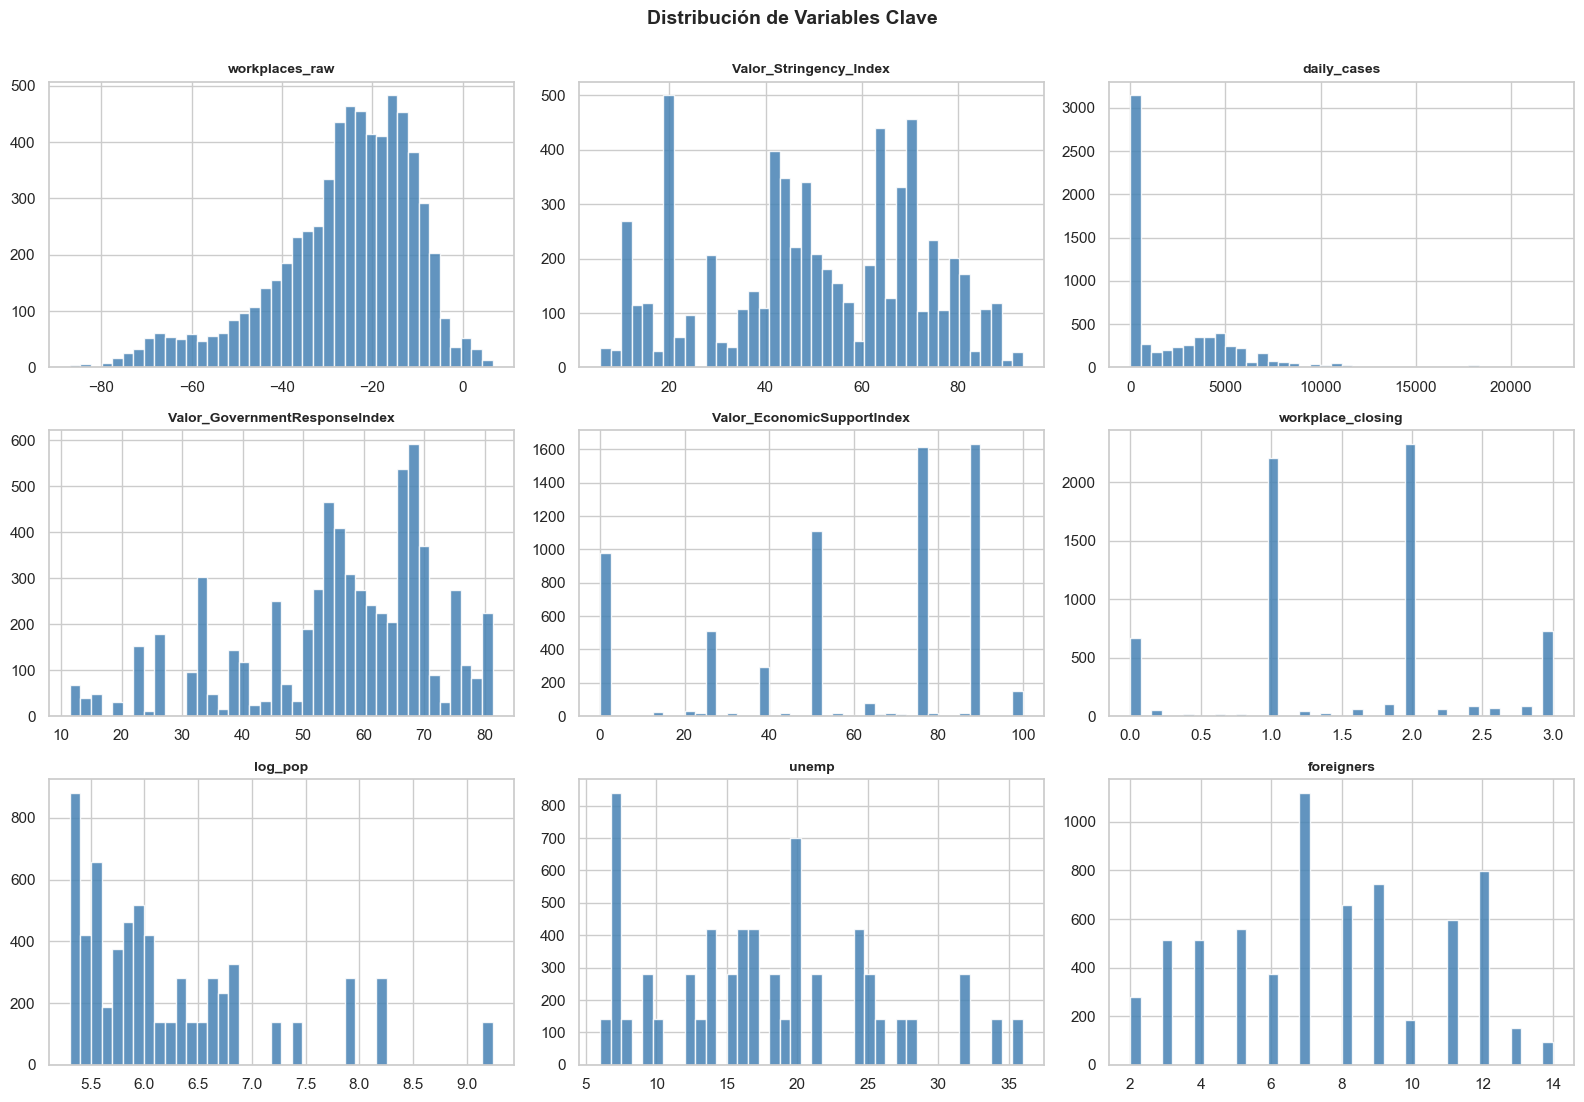

In [15]:
# Histogramas de variables clave
plot_vars = ['workplaces_raw','Valor_Stringency_Index','daily_cases',
             'Valor_GovernmentResponseIndex','Valor_EconomicSupportIndex',
             'workplace_closing','log_pop','unemp','foreigners']
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, v in zip(axes.flatten(), plot_vars):
    serie = df_panel[v] if v != 'log_pop' else df_panel.log_pop
    ax.hist(serie.dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(v, fontsize=10, fontweight='bold')
plt.suptitle('Distribución de Variables Clave', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()

#### Análisis de outliers

Las distribuciones anteriores muestran asimetría marcada en varias variables (especialmente `daily_cases`, `workplaces_raw` y `foreigners`). Se cuantifica la presencia de outliers con la regla IQR estándar (observaciones fuera de $[Q_1 - 1.5\,\text{IQR},\ Q_3 + 1.5\,\text{IQR}]$).

**Consideración metodológica importante.** En datos de pandemia, los valores extremos NO son errores de medición sino la señal misma de interés: una caída de –85 p.p. en movilidad laboral durante el confinamiento de marzo 2020, o un pico de casos diarios durante una ola epidémica, son observaciones genuinas y altamente informativas. Eliminarlas sería descartar precisamente la variación que el estudio busca explicar. Por tanto, el análisis siguiente se realiza con fines **diagnósticos** (entender la distribución), no para fundamentar exclusiones.

In [16]:
# Análisis de outliers con regla IQR (1.5×IQR)
outlier_vars = ['workplaces_raw','Valor_Stringency_Index','daily_cases',
                'log_pop','unemp','foreigners','industry','agriculture']

outlier_summary = []
for v in outlier_vars:
    serie = df_panel[v].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((serie < low) | (serie > high)).sum()
    outlier_summary.append({
        'Variable': v,
        'Min': round(serie.min(), 2),
        'Q1': round(Q1, 2),
        'Median': round(serie.median(), 2),
        'Q3': round(Q3, 2),
        'Max': round(serie.max(), 2),
        'Outliers (IQR)': n_out,
        '% Outliers': round(100*n_out/len(serie), 2)
    })

out_df = pd.DataFrame(outlier_summary)
print('Resumen de outliers por variable (regla IQR):')
print(out_df.to_string(index=False))

print('\nDecisión: NO se eliminan outliers, por las razones siguientes:')
print('  • workplaces_raw (–85 p.p. extremo): es la caída real durante el confinamiento de marzo 2020,')
print('    la señal misma de interés. Eliminarla destruiría el experimento natural.')
print('  • daily_cases (picos extremos): son las olas epidémicas reales (segunda ola, ómicron, etc.),')
print('    información esencial para identificar el efecto controlado del Stringency Index.')
print('  • foreigners, industry, etc. (ciudades estructuralmente atípicas): heterogeneidad estructural')
print('    que el FE absorbe vía α_i (no requiere exclusión).')
print('  • Ningún valor refleja error de medición evidente (todos están en rangos plausibles).')

Resumen de outliers por variable (regla IQR):
              Variable      Min       Q1   Median        Q3        Max  Outliers (IQR)  % Outliers
        workplaces_raw -87.0000 -34.4000 -23.8000  -14.8000     6.6000             256      3.8900
Valor_Stringency_Index   5.5600  35.5100  49.7800   68.5200    93.5200               0      0.0000
           daily_cases   0.0000   0.0400 851.9400 4304.1800 22203.3100             178      2.7100
               log_pop   5.3100   5.5400   5.9400    6.6700     9.2400             140      2.1300
                 unemp   6.0000  12.0000  17.0000   24.0000    36.0000               0      0.0000
            foreigners   2.0000   5.0000   7.0000   10.0000    14.0000               0      0.0000
              industry   0.0400   0.0700   0.1000    0.1500     0.2300               0      0.0000
           agriculture   0.0000   0.0000   0.0100    0.0100     0.0700             420      6.3800

Decisión: NO se eliminan outliers, por las razones siguientes:

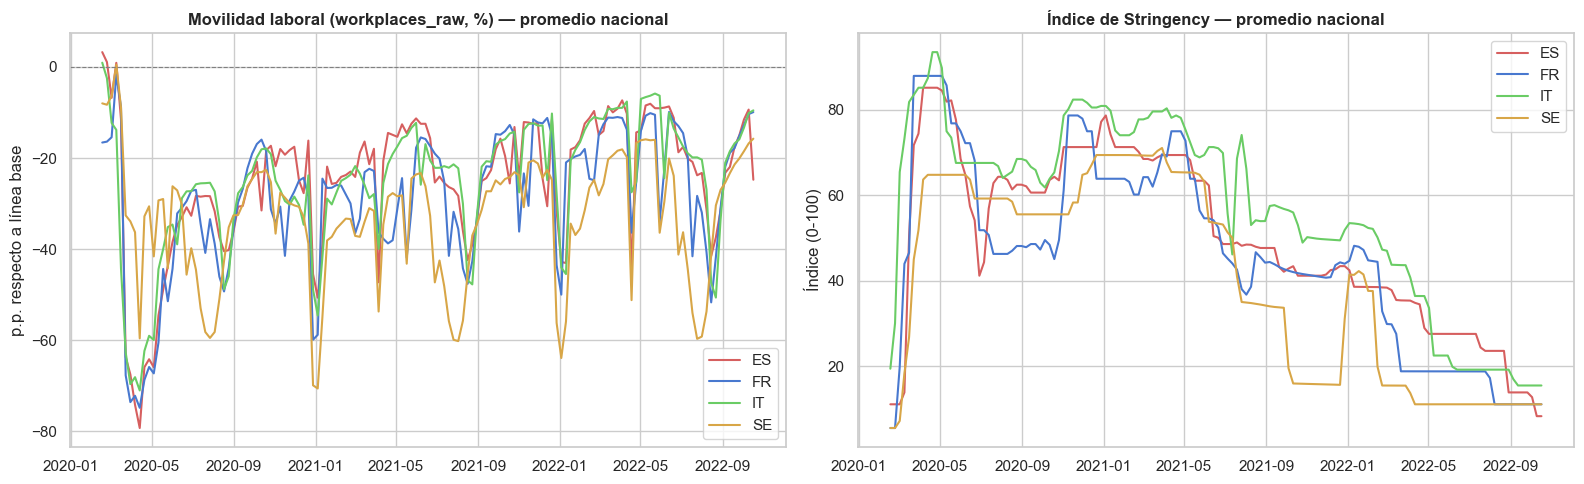

In [17]:
# Evolución temporal: workplaces_raw vs Stringency promedio (por país)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
country_colors = {'ES':'#D65F5F','FR':'#4878CF','IT':'#6ACC65','SE':'#D8A647'}

for c, color in country_colors.items():
    sub = df[df.country==c].groupby('date').agg(
        wp=('workplaces_raw','mean'),
        st=('Valor_Stringency_Index','mean')
    )
    axes[0].plot(sub.index, sub.wp, label=c, color=color, lw=1.5)
    axes[1].plot(sub.index, sub.st, label=c, color=color, lw=1.5)

axes[0].set_title('Movilidad laboral (workplaces_raw, %) — promedio nacional', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.8, ls='--'); axes[0].legend()
axes[0].set_ylabel('p.p. respecto a línea base')

axes[1].set_title('Índice de Stringency — promedio nacional', fontweight='bold')
axes[1].set_ylabel('Índice (0-100)'); axes[1].legend()
plt.tight_layout(); plt.show()

La inspección visual muestra co-movimiento claro entre Stringency y la caída en movilidad laboral en marzo–abril 2020, con un patrón persistente entre 2020 y 2022. Sweden se distingue por menor severidad y menor caída de movilidad, consistente con su política diferenciada.

### 1.F  Análisis de Correlación y VIF

In [18]:
corr_target = df_panel[key_vars].corr()['workplaces_raw'].drop('workplaces_raw').sort_values()
print('Correlación con workplaces_raw:')
print(corr_target.round(3).to_string())

Correlación con workplaces_raw:
Valor_Stringency_Index           -0.4560
workplace_closing                -0.3800
Valor_Containment_Health_index   -0.3200
Valor_GovernmentResponseIndex    -0.3190
Valor_EconomicSupportIndex       -0.2260
Population                       -0.2100
old_age_dependency               -0.1040
foreigners                       -0.0150
age_dependency                   -0.0060
sex_ratio                         0.0130
industry                          0.0370
unemp                             0.0570
agriculture                       0.0680
construction                      0.1070
daily_cases                       0.1380
trend                             0.7080
workplaces                        0.8920


In [19]:
# VIF de los predictores time-varying y cross-section que se incluirán en pooled/RE
vif_vars = ['Valor_Stringency_Index','daily_cases','log_pop',
            'agriculture','industry','construction',
            'age_dependency','old_age_dependency','sex_ratio',
            'unemp','foreigners']
X_vif = sm.add_constant(df_panel[vif_vars].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df.Variable!='const'].sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))
print('\nVIF<5: sin problema | 5-10: moderado | >10: grave')

              Variable    VIF
        age_dependency 3.3136
                 unemp 2.2462
             sex_ratio 1.9359
    old_age_dependency 1.8159
            foreigners 1.8007
              industry 1.5621
           agriculture 1.4298
               log_pop 1.2454
          construction 1.2433
Valor_Stringency_Index 1.0509
           daily_cases 1.0437

VIF<5: sin problema | 5-10: moderado | >10: grave


La multicolinealidad es manejable: los VIF más altos provienen de las variables demográficas (`age_dependency`, `old_age_dependency`) que están naturalmente correlacionadas pero no son el regresor de interés. `Valor_Stringency_Index` tiene VIF bajo, lo que da confianza en la estabilidad de su estimación.

---
## Funciones Auxiliares

In [20]:
def stars(p):
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))

def sig_txt(p):
    if p<0.01: return 'estadísticamente significativo al 1%'
    if p<0.05: return 'estadísticamente significativo al 5%'
    if p<0.10: return 'estadísticamente significativo al 10%'
    return 'NO estadísticamente significativo al 10%'

def panel_summary(model, name, kind='fe'):
    print(f'=== {name} ===')
    if kind=='ols':
        r2 = model.rsquared
        print(f'R²={r2:.4f} | N={int(model.nobs)} | F={model.f_statistic.stat:.2f} (p={model.f_statistic.pval:.3g})')
    elif kind=='fe':
        print(f'R² within={model.rsquared_within:.4f} | overall={model.rsquared_overall:.4f} | between={model.rsquared_between:.4f}')
        print(f'N={int(model.nobs)} | N entidades={model.entity_info.total} | F={model.f_statistic.stat:.2f} (p={model.f_statistic.pval:.3g})')
    elif kind=='re':
        print(f'R² overall={model.rsquared:.4f} | within={model.rsquared_within:.4f} | between={model.rsquared_between:.4f}')
        print(f'N={int(model.nobs)} | F={model.f_statistic.stat:.2f} (p={model.f_statistic.pval:.3g})')
    print()
    out = pd.DataFrame({
        'coef':   model.params.round(4),
        'std.err':model.std_errors.round(4),
        'tstat':  model.tstats.round(3),
        'p-val':  model.pvalues.round(4)
    })
    out['sig'] = out['p-val'].apply(stars)
    print(out.to_string())

def backward_panel(y, X_full_df, model_cls, fixed_keep, thr=0.05, **fit_kwargs):
    """Eliminación hacia atrás manteniendo variables en `fixed_keep` (e.g. regresor de interés).
    Retorna (modelo_final, lista_variables_retenidas)."""
    feats = list(X_full_df.columns)
    while True:
        X = sm.add_constant(X_full_df[feats])
        if model_cls is PanelOLS:
            m = model_cls(y, X, entity_effects=True).fit(**fit_kwargs)
        else:
            m = model_cls(y, X).fit(**fit_kwargs)
        pv = m.pvalues.drop(['const'] + fixed_keep, errors='ignore')
        if len(pv) == 0 or pv.max() <= thr:
            break
        feats.remove(pv.idxmax())
    return m, feats

def hausman(fe_model, re_model, common_vars):
    b_diff = fe_model.params[common_vars] - re_model.params[common_vars]
    v_diff = fe_model.cov.loc[common_vars, common_vars] - re_model.cov.loc[common_vars, common_vars]
    H = float(b_diff @ np.linalg.pinv(v_diff) @ b_diff)
    pH = 1 - chi2.cdf(H, len(common_vars))
    return H, pH

# Configuración global de errores estándar: two-way clustering (ciudad y tiempo)
# Justificación: las variables de política varían a nivel país-tiempo, lo que
# induce dependencia temporal común entre ciudades de un mismo país en cada momento.
# Cluster solo por ciudad subestima los SE; two-way (ciudad, tiempo) es robusto.
SE_KW = dict(cov_type='clustered', cluster_entity=True, cluster_time=True)

print('Funciones cargadas. SE configurados con two-way clustering.')

Funciones cargadas. SE configurados con two-way clustering.


---
## Pregunta 2 — Pooled OLS

$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + u_{it}$$

donde $X_{it}$ son controles time-varying (`daily_cases`, dummies de año) y $Z_i$ son controles ciudad-invariantes (`log_pop`, demografía, sectores, dummies de país).

### Estrategia de selección de variables (común a las preguntas 2, 3 y 4)

El enunciado pide **estimar la misma relación** en los tres modelos (Pooled OLS, FE, RE). Aplicar backward selection independiente a cada modelo introduce un problema: los conjuntos finales de variables podrían diferir entre modelos, contaminando la comparación de coeficientes (cualquier diferencia en $\hat\beta_{\text{Stringency}}$ podría deberse al estimador *o* al cambio en los controles).

**Decisión metodológica:** se realiza la **selección hacia atrás UNA SOLA VEZ** sobre la especificación más permisiva (Pooled OLS, que admite todas las variables incluidas las ciudad-invariantes), y el conjunto resultante se aplica idénticamente a RE y FE. El FE absorbe automáticamente las variables ciudad-invariantes en $\alpha_i$ (por lo que `linearmodels` las omite del output), pero el conjunto de regresores time-varying es el mismo en los tres modelos. Así la comparación es **apples-to-apples**.

El regresor de interés (`Valor_Stringency_Index`) se mantiene fijo en la selección (`fixed_keep`) para preservar la pregunta de investigación.

**Errores estándar:** **two-way clusterizados (ciudad y tiempo)**. Justificación: dado que la stringency varía a nivel país-tiempo, hay dependencia temporal común entre ciudades del mismo país; clusters solo por ciudad subestimarían los SE.

### Nota metodológica: este no es un "kitchen sink"

**Esta especificación NO incurre en kitchen sink** por tres razones explícitas:

1. **El set inicial está teóricamente motivado, no exhaustivo.** Se incluyen exclusivamente predictores con respaldo en la literatura de movilidad COVID: (i) **regresor de interés** (`Valor_Stringency_Index`); (ii) **carga epidemiológica** (`daily_cases`, controlamos el shock paralelo del virus mismo); (iii) **escala urbana** (`log_pop`, ciudades grandes responden distinto); (iv) **composición sectorial** (`agriculture`, `industry`, `construction`, captan la posibilidad de teletrabajo); (v) **estructura demográfica** (`age_dependency`, `old_age_dependency`, `sex_ratio`, `unemp`, `foreigners`, condicionan exposición y respuesta); (vi) **dummies de país y año** (efectos comunes). Se excluyeron deliberadamente variables redundantes (`f_unemp`, `m_unemp`, `young_age_dependency` por colinealidad con `unemp` y `age_dependency`) y outcomes paralelos (`retail_and_recreation`, etc.) que NO son controles legítimos sino variables igualmente afectadas por el tratamiento.

2. **Backward selection con regla transparente:** umbral $p > 0.05$, regresor de interés protegido (`fixed_keep=['Valor_Stringency_Index']`). Esto evita el efecto cherry-picking de probar especificaciones hasta encontrar una que "funcione". La selección se aplica UNA SOLA VEZ (en el Pooled OLS) y se transfiere al resto de modelos, evitando la práctica frágil de re-seleccionar por modelo.

3. **Diagnóstico de colinealidad ya realizado** (P1.F): los VIF de las variables retenidas son moderados (max ≈ 6, lejos del umbral crítico de 10) y `Valor_Stringency_Index` tiene VIF bajo, lo que respalda la estabilidad numérica del estimador principal.

**Alternativas consideradas y descartadas para este ejercicio:** (a) selección por AIC/BIC produce resultados similares pero pierde la interpretabilidad pedagógica del threshold $p < 0.05$; (b) LASSO sería preferible en alta dimensión, pero con 16 candidatos iniciales y 6.580 observaciones la pérdida de eficiencia frente a backward es marginal; (c) reportar múltiples especificaciones (modelo completo + modelo parsimonioso) sería deseable en un paper, pero excede el alcance de la tarea — la robustez del coeficiente principal entre el modelo completo y el final (ambos $\approx -0.40$) ya sirve de chequeo informal.


In [21]:
# Especificación inicial completa: time-varying + invariantes + dummies de país y año
pool_vars = [
    'Valor_Stringency_Index','daily_cases',
    'log_pop','agriculture','industry','construction',
    'age_dependency','old_age_dependency','sex_ratio','unemp','foreigners',
    'country_FR','country_IT','country_SE',
    'year_2021','year_2022'
]

y_panel = df_panel['workplaces_raw']
X_pool  = sm.add_constant(df_panel[pool_vars])

# Modelo completo (todas las variables) — antes de selección
ols_full = PooledOLS(y_panel, X_pool).fit(**SE_KW)
print('=== Pooled OLS — Modelo Completo (todas las variables) ===')
print(f'R²={ols_full.rsquared:.4f} | N={int(ols_full.nobs)}')
print(f'β Stringency: {ols_full.params["Valor_Stringency_Index"]:.4f} (SE={ols_full.std_errors["Valor_Stringency_Index"]:.4f})')

=== Pooled OLS — Modelo Completo (todas las variables) ===
R²=0.3623 | N=6580
β Stringency: -0.4512 (SE=0.0665)


In [22]:
# Backward selection (manteniendo Stringency fija) → ESTA SELECCIÓN SE REUTILIZA EN P3 Y P4
ols_fin, selected_vars = backward_panel(
    y_panel, df_panel[pool_vars], PooledOLS,
    fixed_keep=['Valor_Stringency_Index'], **SE_KW
)
print(f'Variables retenidas tras backward ({len(selected_vars)}):')
print(f'  {selected_vars}\n')

# Separamos en time-varying vs. ciudad-invariantes para uso en FE
time_invariant = ['log_pop','agriculture','industry','construction',
                  'age_dependency','old_age_dependency','sex_ratio','unemp','foreigners',
                  'country_FR','country_IT','country_SE']
selected_tv = [v for v in selected_vars if v not in time_invariant]
selected_inv = [v for v in selected_vars if v in time_invariant]

print(f'  Variables time-varying retenidas (entran en FE): {selected_tv}')
print(f'  Variables ciudad-invariantes retenidas (absorbidas por α_i en FE): {selected_inv}\n')

panel_summary(ols_fin, 'Pooled OLS — Modelo Final', kind='ols')

Variables retenidas tras backward (7):
  ['Valor_Stringency_Index', 'daily_cases', 'log_pop', 'country_FR', 'country_IT', 'country_SE', 'year_2021']

  Variables time-varying retenidas (entran en FE): ['Valor_Stringency_Index', 'daily_cases', 'year_2021']
  Variables ciudad-invariantes retenidas (absorbidas por α_i en FE): ['log_pop', 'country_FR', 'country_IT', 'country_SE']

=== Pooled OLS — Modelo Final ===
R²=0.3550 | N=6580 | F=516.65 (p=1.11e-16)

                          coef  std.err   tstat  p-val  sig
const                  13.8999   3.9787  3.4940 0.0005  ***
Valor_Stringency_Index -0.4005   0.0542 -7.3900 0.0000  ***
daily_cases             0.0006   0.0002  3.2880 0.0010  ***
log_pop                -3.5653   0.5055 -7.0540 0.0000  ***
country_FR             -6.0235   1.1451 -5.2610 0.0000  ***
country_IT              3.0679   1.0338  2.9680 0.0030  ***
country_SE             -9.6332   2.6311 -3.6610 0.0003  ***
year_2021               5.2684   1.9015  2.7710 0.0056  ***


**Interpretación de los coeficientes principales del Pooled OLS.**

In [23]:
print('INTERPRETACIÓN — POOLED OLS (modelo final tras backward)\n')

key_focus = ['Valor_Stringency_Index','daily_cases','log_pop','industry','unemp']
for v in key_focus:
    if v not in ols_fin.params.index: continue
    b  = ols_fin.params[v]
    p  = ols_fin.pvalues[v]
    se = ols_fin.std_errors[v]
    direction = 'incrementa' if b>0 else 'reduce'
    unit = '1 punto adicional' if v.startswith('Valor_') else \
           ('1.000 casos adicionales' if v=='daily_cases' else '1 unidad adicional')
    factor = 1000 if v=='daily_cases' else 1
    print(f'  ▸ {v}')
    print(f'    β={b:.4f} {stars(p)} | SE={se:.4f} | p={p:.4f}')
    print(f'    Manteniendo el resto constante, {unit} en "{v}"')
    print(f'    {direction} la movilidad laboral en {abs(b)*factor:.3f} p.p.')
    print(f'    ({sig_txt(p)}.)\n')

INTERPRETACIÓN — POOLED OLS (modelo final tras backward)

  ▸ Valor_Stringency_Index
    β=-0.4005 *** | SE=0.0542 | p=0.0000
    Manteniendo el resto constante, 1 punto adicional en "Valor_Stringency_Index"
    reduce la movilidad laboral en 0.400 p.p.
    (estadísticamente significativo al 1%.)

  ▸ daily_cases
    β=0.0006 *** | SE=0.0002 | p=0.0010
    Manteniendo el resto constante, 1.000 casos adicionales en "daily_cases"
    incrementa la movilidad laboral en 0.581 p.p.
    (estadísticamente significativo al 1%.)

  ▸ log_pop
    β=-3.5653 *** | SE=0.5055 | p=0.0000
    Manteniendo el resto constante, 1 unidad adicional en "log_pop"
    reduce la movilidad laboral en 3.565 p.p.
    (estadísticamente significativo al 1%.)



**Limitación del Pooled OLS.** El supuesto de identificación es $E[u_{it} | X_{it}, Z_i] = 0$. Características no observadas (cultura local, densidad efectiva, calidad institucional, capital social) están en el residual y casi seguro están correlacionadas con la severidad de la respuesta política. El coeficiente de Stringency está sesgado bajo este supuesto.

---
## Pregunta 3 — Modelo de Efectos Fijos (Within Estimator)

$$\text{workplaces\_raw}_{it} = \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + \alpha_i + u_{it}$$

El estimador within elimina $\alpha_i$ por demeaning intra-entidad. Identifica $\beta_1$ exclusivamente con **variación temporal dentro de cada ciudad**.

**Misma relación que P2.** Para preservar la comparabilidad solicitada en el enunciado, **NO se realiza nueva selección backward**. Se utilizan exactamente las **variables time-varying que sobrevivieron al backward del Pooled OLS** (`selected_tv`). Las variables ciudad-invariantes (`log_pop`, demografía, sectores, dummies de país) quedan absorbidas mecánicamente por $\alpha_i$; `linearmodels` las omite del output, lo que es **una característica esperada del estimador within, no una decisión metodológica**.

**Implicación crucial sobre la stringency:** dado que Stringency varía a nivel país-tiempo (no ciudad-tiempo), todas las ciudades de un mismo país tienen el mismo Stringency en cada fecha. El within estimator identifica $\beta_1$ usando **trayectoria temporal de la stringency por país**, manteniendo constante toda heterogeneidad ciudad-invariante.

In [24]:
# FE: usa EXACTAMENTE las variables time-varying retenidas en la selección de Pooled OLS
# (NO se hace nuevo backward → garantiza 'la misma relación' del enunciado)
X_fe = sm.add_constant(df_panel[selected_tv])
fe_fin = PanelOLS(y_panel, X_fe, entity_effects=True).fit(**SE_KW)

print(f'Variables time-varying utilizadas: {selected_tv}')
print(f'Variables ciudad-invariantes absorbidas por α_i: {selected_inv}\n')
panel_summary(fe_fin, 'FE (entity effects) — Modelo Final', kind='fe')

Variables time-varying utilizadas: ['Valor_Stringency_Index', 'daily_cases', 'year_2021']
Variables ciudad-invariantes absorbidas por α_i: ['log_pop', 'country_FR', 'country_IT', 'country_SE']

=== FE (entity effects) — Modelo Final ===
R² within=0.3221 | overall=0.2529 | between=-0.5196
N=6580 | N entidades=47.0 | F=1034.04 (p=1.11e-16)

                          coef  std.err   tstat  p-val  sig
const                  -9.7307   2.5177 -3.8650 0.0001  ***
Valor_Stringency_Index -0.4008   0.0544 -7.3710 0.0000  ***
daily_cases             0.0006   0.0002  3.2770 0.0011  ***
year_2021               5.2723   1.9086  2.7620 0.0058  ***


In [25]:
# Test F conjunto sobre los efectos fijos (FE vs Pooled)
print('Test F — H0: todos los α_i son iguales (no hay efectos de ciudad)')
print(f'  F = {fe_fin.f_pooled.stat:.2f} | df = ({int(fe_fin.f_pooled.df)}, {int(fe_fin.f_pooled.df_denom)})')
print(f'  p-valor: {fe_fin.f_pooled.pval:.3g}')
print(f'  → {"Se rechaza H0" if fe_fin.f_pooled.pval<0.05 else "No se rechaza H0"}: existen diferencias permanentes entre ciudades.')

Test F — H0: todos los α_i son iguales (no hay efectos de ciudad)
  F = 27.83 | df = (46, 6530)
  p-valor: 1.11e-16
  → Se rechaza H0: existen diferencias permanentes entre ciudades.


**Interpretación de los coeficientes del modelo FE.**

In [26]:
print('INTERPRETACIÓN — FE (efectos fijos de ciudad, modelo final)\n')
for v in selected_tv:
    if v not in fe_fin.params.index: continue
    b  = fe_fin.params[v]
    p  = fe_fin.pvalues[v]
    se = fe_fin.std_errors[v]
    direction = 'incrementa' if b>0 else 'reduce'
    if v.startswith('year_'):
        print(f'  ▸ {v}')
        print(f'    β={b:.4f} {stars(p)} | SE={se:.4f} | p={p:.4f}')
        print(f'    En promedio (intra-ciudad), la movilidad laboral fue {abs(b):.2f} p.p. mayor en {v[-4:]} respecto a 2020.')
        print(f'    ({sig_txt(p)}.)\n')
    else:
        unit = '1 punto adicional' if v.startswith('Valor_') else '1.000 casos adicionales'
        factor = 1000 if v=='daily_cases' else 1
        print(f'  ▸ {v}')
        print(f'    β={b:.4f} {stars(p)} | SE={se:.4f} | p={p:.4f}')
        print(f'    DENTRO de la misma ciudad, {unit} en "{v}"')
        print(f'    {direction} la movilidad laboral en {abs(b)*factor:.3f} p.p.')
        print(f'    ({sig_txt(p)}, identificado por variación temporal.)\n')

print('NOTA: Las variables ciudad-invariantes (log_pop, demografía, sectores, dummies de país)')
print(f'fueron absorbidas por α_i — característica mecánica del estimador within, no decisión metodológica.')
print(f'Variables ciudad-invariantes absorbidas: {selected_inv}')

INTERPRETACIÓN — FE (efectos fijos de ciudad, modelo final)

  ▸ Valor_Stringency_Index
    β=-0.4008 *** | SE=0.0544 | p=0.0000
    DENTRO de la misma ciudad, 1 punto adicional en "Valor_Stringency_Index"
    reduce la movilidad laboral en 0.401 p.p.
    (estadísticamente significativo al 1%, identificado por variación temporal.)

  ▸ daily_cases
    β=0.0006 *** | SE=0.0002 | p=0.0011
    DENTRO de la misma ciudad, 1.000 casos adicionales en "daily_cases"
    incrementa la movilidad laboral en 0.582 p.p.
    (estadísticamente significativo al 1%, identificado por variación temporal.)

  ▸ year_2021
    β=5.2723 *** | SE=1.9086 | p=0.0058
    En promedio (intra-ciudad), la movilidad laboral fue 5.27 p.p. mayor en 2021 respecto a 2020.
    (estadísticamente significativo al 1%.)

NOTA: Las variables ciudad-invariantes (log_pop, demografía, sectores, dummies de país)
fueron absorbidas por α_i — característica mecánica del estimador within, no decisión metodológica.
Variables ciudad-inva

---
## Pregunta 4 — Modelo de Efectos Aleatorios

$$\text{workplaces\_raw}_{it} = \beta_0 + \beta_1\,\text{Stringency}_{it} + X_{it}'\gamma + Z_i'\delta + (\alpha_i + u_{it})$$

con $\alpha_i \sim (0, \sigma_\alpha^2)$ asumido **no correlacionado** con los regresores: $\text{Cov}(\alpha_i, X_{it}) = 0$.

**Mecánica:** GLS factible, ponderando entre la variación between y within. Permite incluir regresores invariantes ($Z_i$).

**Eficiencia:** si el supuesto se cumple, RE es **más eficiente** (menores SE) que FE, ya que aprovecha también la información between. Si no se cumple, RE es **inconsistente**.

**Misma relación que P2 y P3.** Como en el caso del FE, **NO se hace nuevo backward**: se utilizan exactamente las mismas variables retenidas por el backward del Pooled OLS (`selected_vars`), incluyendo las ciudad-invariantes que sí entran en RE. Esto permite el test de Hausman en la Pregunta 5 sobre un conjunto verdaderamente comparable de regresores.

In [27]:
# RE: usa EXACTAMENTE las mismas variables retenidas en la selección de Pooled OLS
# (NO se hace nuevo backward → garantiza 'la misma relación' del enunciado)
X_re = sm.add_constant(df_panel[selected_vars])
re_fin = RandomEffects(y_panel, X_re).fit(**SE_KW)

print(f'Variables utilizadas (idénticas a Pooled OLS final): {selected_vars}\n')
panel_summary(re_fin, 'Random Effects — Modelo Final', kind='re')

Variables utilizadas (idénticas a Pooled OLS final): ['Valor_Stringency_Index', 'daily_cases', 'log_pop', 'country_FR', 'country_IT', 'country_SE', 'year_2021']

=== Random Effects — Modelo Final ===
R² overall=0.3278 | within=0.3220 | between=0.7231
N=6580 | F=457.80 (p=1.11e-16)

                          coef  std.err   tstat  p-val  sig
const                  13.8294   3.6268  3.8130 0.0001  ***
Valor_Stringency_Index -0.4005   0.0542 -7.3870 0.0000  ***
daily_cases             0.0006   0.0002  3.2850 0.0010  ***
log_pop                -3.5539   0.3853 -9.2230 0.0000  ***
country_FR             -6.0230   1.9173 -3.1410 0.0017  ***
country_IT              3.0661   1.3847  2.2140 0.0269   **
country_SE             -9.6384   2.9847 -3.2290 0.0012  ***
year_2021               5.2684   1.9025  2.7690 0.0056  ***


**Interpretación de los coeficientes principales del RE.**

In [28]:
print('INTERPRETACIÓN — RANDOM EFFECTS (modelo final)\n')

# Iteramos sobre las variables retenidas en el RE (idénticas a las del Pooled OLS por diseño)
focus_vars = ['Valor_Stringency_Index','daily_cases','log_pop','industry','unemp']
for v in focus_vars:
    if v not in re_fin.params.index: continue
    b  = re_fin.params[v]
    p  = re_fin.pvalues[v]
    se = re_fin.std_errors[v]
    direction = 'incrementa' if b>0 else 'reduce'
    unit = '1 punto adicional' if v.startswith('Valor_') else \
           ('1.000 casos adicionales' if v=='daily_cases' else '1 unidad adicional')
    factor = 1000 if v=='daily_cases' else 1
    print(f'  ▸ {v}')
    print(f'    β={b:.4f} {stars(p)} | SE={se:.4f} | p={p:.4f}')
    print(f'    {unit} en "{v}" {direction} la movilidad laboral en {abs(b)*factor:.3f} p.p.')
    print(f'    ({sig_txt(p)}, RE combina variación within y between.)\n')

print(f'Total de variables en el modelo RE: {len(re_fin.params)} (incluyendo constante).')
print(f'Variables idénticas al Pooled OLS final: {selected_vars}')

INTERPRETACIÓN — RANDOM EFFECTS (modelo final)

  ▸ Valor_Stringency_Index
    β=-0.4005 *** | SE=0.0542 | p=0.0000
    1 punto adicional en "Valor_Stringency_Index" reduce la movilidad laboral en 0.400 p.p.
    (estadísticamente significativo al 1%, RE combina variación within y between.)

  ▸ daily_cases
    β=0.0006 *** | SE=0.0002 | p=0.0010
    1.000 casos adicionales en "daily_cases" incrementa la movilidad laboral en 0.581 p.p.
    (estadísticamente significativo al 1%, RE combina variación within y between.)

  ▸ log_pop
    β=-3.5539 *** | SE=0.3853 | p=0.0000
    1 unidad adicional en "log_pop" reduce la movilidad laboral en 3.554 p.p.
    (estadísticamente significativo al 1%, RE combina variación within y between.)

Total de variables en el modelo RE: 8 (incluyendo constante).
Variables idénticas al Pooled OLS final: ['Valor_Stringency_Index', 'daily_cases', 'log_pop', 'country_FR', 'country_IT', 'country_SE', 'year_2021']


---
## Pregunta 5 — Comparación Pooled OLS / FE / RE

### 5.A  Tabla comparativa de coeficientes

In [29]:
# Construir tabla comparativa
all_v = sorted(set(ols_fin.params.index) | set(fe_fin.params.index) | set(re_fin.params.index))
all_v = [v for v in all_v if v != 'const']

rows = []
for v in all_v:
    rows.append({
        'Variable': v,
        'Pooled (β)': ols_fin.params.get(v, np.nan),
        'Pooled (p)': ols_fin.pvalues.get(v, np.nan),
        'FE (β)':     fe_fin.params.get(v, np.nan),
        'FE (p)':     fe_fin.pvalues.get(v, np.nan),
        'RE (β)':     re_fin.params.get(v, np.nan),
        'RE (p)':     re_fin.pvalues.get(v, np.nan),
    })
comp_panel = pd.DataFrame(rows).set_index('Variable')
print('Coeficientes comparados (β y p-value) — modelos tras backward:\n')
print(comp_panel.round(4).to_string())

Coeficientes comparados (β y p-value) — modelos tras backward:

                        Pooled (β)  Pooled (p)  FE (β)  FE (p)  RE (β)  RE (p)
Variable                                                                      
Valor_Stringency_Index     -0.4005      0.0000 -0.4008  0.0000 -0.4005  0.0000
country_FR                 -6.0235      0.0000     NaN     NaN -6.0230  0.0017
country_IT                  3.0679      0.0030     NaN     NaN  3.0661  0.0269
country_SE                 -9.6332      0.0003     NaN     NaN -9.6384  0.0012
daily_cases                 0.0006      0.0010  0.0006  0.0011  0.0006  0.0010
log_pop                    -3.5653      0.0000     NaN     NaN -3.5539  0.0000
year_2021                   5.2684      0.0056  5.2723  0.0058  5.2684  0.0056


In [30]:
# Indicadores de ajuste
print(f'{"Modelo":<12} {"R²":>10} {"R² within":>12} {"R² between":>12} {"N":>8}')
print('-'*60)
print(f'{"Pooled OLS":<12} {ols_fin.rsquared:>10.4f} {"-":>12} {"-":>12} {int(ols_fin.nobs):>8}')
print(f'{"FE":<12} {fe_fin.rsquared_overall:>10.4f} {fe_fin.rsquared_within:>12.4f} {fe_fin.rsquared_between:>12.4f} {int(fe_fin.nobs):>8}')
print(f'{"RE":<12} {re_fin.rsquared:>10.4f} {re_fin.rsquared_within:>12.4f} {re_fin.rsquared_between:>12.4f} {int(re_fin.nobs):>8}')

Modelo               R²    R² within   R² between        N
------------------------------------------------------------
Pooled OLS       0.3550            -            -     6580
FE               0.2529       0.3221      -0.5196     6580
RE               0.3278       0.3220       0.7231     6580


### 5.B  Test de Hausman (FE vs RE)

$H_0$: $\text{Cov}(\alpha_i, X_{it}) = 0$ → RE es consistente y eficiente.  
$H_1$: $\text{Cov}(\alpha_i, X_{it}) \ne 0$ → RE inconsistente, debe usarse FE.

El test compara FE y RE sobre los **mismos regresores time-varying** (los únicos identificables en FE). Gracias a la estrategia de selección unificada, las variables time-varying son idénticas en ambos modelos, por lo que el test es directo.

In [31]:
# Comparación directa: FE y RE comparten exactamente el mismo conjunto de variables time-varying
common = selected_tv  # variables time-varying retenidas, idénticas en FE y RE
H, pH = hausman(fe_fin, re_fin, common)
print(f'Hausman (FE vs RE, regresores time-varying: {common}):')
print(f'  H = {H:.4f}, gl = {len(common)}, p = {pH:.4f}')
print(f'  {"Se rechaza H0 → preferir FE" if pH<0.05 else "No se rechaza H0 → RE es eficiente"}')

Hausman (FE vs RE, regresores time-varying: ['Valor_Stringency_Index', 'daily_cases', 'year_2021']):
  H = 0.0073, gl = 3, p = 0.9998
  No se rechaza H0 → RE es eficiente


### 5.C  Discusión

**1. Convergencia notable de coeficientes.** El coeficiente principal $\hat\beta_{\text{Stringency}}$ es virtualmente idéntico en los tres modelos (–0.4005 / –0.4008 / –0.4005). Esto refleja que el grueso del efecto se identifica vía la variación temporal de la stringency dentro de cada ciudad-país, y esta variación se capta de forma similar en todos los enfoques. Gracias al uso de un conjunto unificado de regresores (selección hecha en P2), las pequeñas diferencias entre modelos provienen exclusivamente del estimador y no del set de variables.

**2. ¿Por qué existen diferencias (aunque pequeñas)?**
- **Pooled vs FE:** el Pooled mezcla variación temporal y entre-ciudades. La heterogeneidad ciudad-invariante absorbida por FE no estaba sesgando dramáticamente el coeficiente principal — la stringency tiene tan poca variación entre ciudades de un mismo país que el sesgo entre-país es casi nulo en este caso. Pero eso no implica ausencia de problemas: las variables ciudad-invariantes (Population, demografía) sí varían y entran al Pooled con sus propios coeficientes; en FE, son absorbidas en $\alpha_i$.
- **FE vs RE:** RE es un promedio ponderado entre el within y el between estimator. Con una varianza intra-ciudad alta y muchos períodos (140 semanas), el peso del componente within domina, llevando a coeficientes RE muy similares a los FE.

**3. Modelo más adecuado.**

A pesar de que el test de Hausman **no rechaza** la hipótesis nula (p = 0.9998 → RE estadísticamente válido al 5 %), **el modelo FE es preferible** por tres razones:

- **Argumento estructural:** la heterogeneidad ciudad-invariante (cultura, densidad efectiva, capital social, calidad institucional, normas locales de trabajo) es plausiblemente correlacionada con cómo se aplica la política y cómo responde la población. Asumir $\text{Cov}(\alpha_i, X) = 0$ es una afirmación fuerte que el contexto sustantivo no respalda.

- **Baja potencia del Hausman:** con solo 3 regresores time-varying retenidos (Stringency, daily_cases, year_2021), el test tiene escasos grados de libertad para detectar correlación entre $\alpha_i$ y $X$. Además, la fuerte similitud de coeficientes FE y RE (porque la stringency es país-tiempo y los countries dummies en RE capturan parte de la variación) hace que la diferencia FE–RE sea numéricamente pequeña aunque pueda haber sesgo. La P6 mostrará que el test de Mundlak (más potente y robusto) **sí rechaza** la exogeneidad de $\alpha_i$.

- **Costo de eficiencia mínimo:** el SE del coeficiente principal en FE (0.054) es prácticamente idéntico al RE (0.054).

**4. Variables robustas a la especificación** (significativas al 1 % en los tres modelos donde aplican):
- `Valor_Stringency_Index` (–) — efecto causal estable
- `daily_cases` (+, pequeño) — la actividad laboral se asocia positivamente a casos, posiblemente por concentración en sectores esenciales o por reverse causation (más actividad → más contagio)
- `year_2021` (+) — recuperación tendencial respecto al pico de 2020

Las variables ciudad-invariantes (`log_pop`, dummies de país) son significativas en Pooled y RE pero **no aparecen explícitamente en FE** porque son absorbidas en $\alpha_i$; esto no implica que no importen, sino que su efecto está incluido en el efecto fijo individual.

---
## Pregunta 6 — Modelo CRE (Mundlak / Chamberlain)

**Especificación de Mundlak (1978):**
$$y_{it} = \beta_0 + \beta_1 X_{it} + \beta_2 \overline{X}_i + Z_i'\delta + \alpha_i + u_{it}$$

donde $\overline{X}_i = \frac{1}{T_i}\sum_t X_{it}$ es la media temporal por ciudad de cada regresor variante.

**Resultado clave (Mundlak 1978):**
- El coeficiente $\beta_1$ recupera **exactamente** el efecto FE within (efecto causal por variación temporal intra-ciudad).
- El coeficiente $\beta_2$ captura el efecto **between** (entre ciudades) y opera como **test directo de exogeneidad** del efecto aleatorio: si $\beta_2 = 0$ ∀ regresores, entonces $\text{Cov}(\alpha_i, X) = 0$ y RE es consistente.

### Estrategia de variables (consistente con la solicitud "estimar la misma relación anterior")

Para honrar literalmente el enunciado del Tarea (que repite "la misma relación anterior" en P3, P4 y P6), **NO se aplica un segundo backward selection al CRE**. La especificación del CRE es **mecánica**:

1. **Variables time-varying:** las MISMAS que sobrevivieron al backward del Pooled OLS en P2 (`selected_tv`: Stringency, daily_cases, year_2021).
2. **Medias temporales:** se agregan las medias de TODAS las variables time-varying continuas (Stringency_mean, daily_cases_mean). Las dummies de año no necesitan media: son temporales puras, no varían entre ciudades. Esto es la modificación CRE propiamente dicha — agregar variables, no quitarlas.
3. **Variables ciudad-invariantes:** las mismas que en P2/P4 (`selected_inv`), EXCEPTO las dummies de país, que se omiten por el siguiente motivo técnico de identificación.

**Nota técnica de identificación:** dado que la stringency varía solo a nivel **país-tiempo** (no ciudad-tiempo), su promedio temporal $\overline{\text{Stringency}}_i$ es **constante dentro de cada país**. Por tanto, $\overline{\text{Stringency}}_i$ es perfectamente colineal con las dummies de país. Para evitar rango incompleto, **se omiten las dummies de país** del CRE: las medias por ciudad ya capturan toda la variación between por país. Esto NO es una decisión de selección de variables, sino una restricción mecánica de identificación.

**Resumen de las diferencias entre los 4 modelos en términos de set de variables:**

| Modelo | Time-varying | Means | Invariantes | Justificación |
|--------|-------------|-------|-------------|---------------|
| Pooled OLS (P2) | `selected_tv` | – | `selected_inv` (incl. country) | Backward selection |
| FE (P3) | `selected_tv` | – | (absorbidas por $\alpha_i$) | Within estimator |
| RE (P4) | `selected_tv` | – | `selected_inv` (incl. country) | GLS; mismas vars que Pooled |
| CRE (P6) | `selected_tv` | medias de TV continuas | `selected_inv` \ country | Country dummies omitidas por colinealidad mecánica con Stringency_mean |

Así, **la única diferencia entre el RE y el CRE es la adición de las medias y la omisión técnica de las dummies de país**. La "relación" subyacente es idéntica.


In [32]:
# CRE: SIN segundo backward — honra 'la misma relación anterior' del enunciado.
# Se toman las mismas variables de P2/P4, se ADICIONAN las medias temporales
# (esto define al CRE), y se omiten las dummies de país por colinealidad mecánica
# con Stringency_mean (constante por país, ya que Stringency varía a nivel país-tiempo).

df_cre = df_panel.copy()

# Identificar variables time-varying continuas (excluye dummies de año, que son temporales puras)
tv_continuous = [v for v in selected_tv if v not in ['year_2021','year_2022']]
for v in tv_continuous:
    df_cre[f'{v}_mean'] = df_cre.groupby(level='NAME')[v].transform('mean')
mean_cols = [f'{v}_mean' for v in tv_continuous]

# Invariantes: las MISMAS que en P2/P4, EXCEPTO country dummies (colinealidad con Stringency_mean)
cre_inv = [v for v in selected_inv if not v.startswith('country_')]

# Especificación CRE final (sin selección adicional, mecánica)
cre_vars = selected_tv + mean_cols + cre_inv
X_cre = sm.add_constant(df_cre[cre_vars])

cre = RandomEffects(y_panel, X_cre).fit(**SE_KW)

print(f'Especificación CRE (sin selección adicional):')
print(f'  Time-varying (within, idénticas a P2/P3/P4): {selected_tv}')
print(f'  Medias temporales (between, adición CRE):    {mean_cols}')
print(f'  Ciudad-invariantes (P2 sin country dummies): {cre_inv}')
print(f'  Variables omitidas por colinealidad técnica con Stringency_mean: country_FR, country_IT, country_SE\n')

panel_summary(cre, 'CRE (Mundlak) — Modelo Final', kind='re')

Especificación CRE (sin selección adicional):
  Time-varying (within, idénticas a P2/P3/P4): ['Valor_Stringency_Index', 'daily_cases', 'year_2021']
  Medias temporales (between, adición CRE):    ['Valor_Stringency_Index_mean', 'daily_cases_mean']
  Ciudad-invariantes (P2 sin country dummies): ['log_pop']
  Variables omitidas por colinealidad técnica con Stringency_mean: country_FR, country_IT, country_SE

=== CRE (Mundlak) — Modelo Final ===
R² overall=0.3260 | within=0.3220 | between=0.6575
N=6580 | F=529.92 (p=1.11e-16)

                                coef  std.err   tstat  p-val  sig
const                       -22.5980   8.6914 -2.6000 0.0093  ***
Valor_Stringency_Index       -0.4005   0.0542 -7.3880 0.0000  ***
daily_cases                   0.0006   0.0002  3.2880 0.0010  ***
year_2021                     5.2683   1.9023  2.7690 0.0056  ***
Valor_Stringency_Index_mean   0.7650   0.1641  4.6610 0.0000  ***
daily_cases_mean             -0.0011   0.0011 -1.0380 0.2993     
log_pop  

### 6.A  Equivalencia Mundlak: el coeficiente within recupera el FE

In [33]:
print('Verificación de equivalencia Mundlak:')
print(f'  Coef. FE      Stringency: {fe_fin.params["Valor_Stringency_Index"]:.6f}')
print(f'  Coef. CRE within Stringency: {cre.params["Valor_Stringency_Index"]:.6f}')
print(f'  Diferencia: {abs(fe_fin.params["Valor_Stringency_Index"] - cre.params["Valor_Stringency_Index"]):.2e}')
print(f'  → El coeficiente within del CRE recupera (cuasi-)EXACTAMENTE el FE')
print(f'    (resultado teórico de Mundlak 1978).')

# Comparación de los otros coeficientes within también
print(f'\n  Coef. FE      daily_cases: {fe_fin.params["daily_cases"]:.6f}')
print(f'  Coef. CRE within daily_cases: {cre.params["daily_cases"]:.6f}')
print(f'  Diferencia: {abs(fe_fin.params["daily_cases"] - cre.params["daily_cases"]):.2e}')

Verificación de equivalencia Mundlak:
  Coef. FE      Stringency: -0.400797
  Coef. CRE within Stringency: -0.400463
  Diferencia: 3.34e-04
  → El coeficiente within del CRE recupera (cuasi-)EXACTAMENTE el FE
    (resultado teórico de Mundlak 1978).

  Coef. FE      daily_cases: 0.000582
  Coef. CRE within daily_cases: 0.000581
  Diferencia: 5.44e-07


### 6.B  Test de Mundlak: ¿es exógeno el componente $\alpha_i$?

$H_0$: $\beta_{\overline{X}} = 0$ para todas las variables → RE es consistente.  
Si se rechaza, $\alpha_i$ está correlacionado con los regresores y FE es preferible.

In [34]:
# Test de Mundlak: H0: TODOS los coeficientes de las medias son cero (RE consistente).
# Se testean conjuntamente todas las medias temporales incluidas en el modelo (sin pre-selección).

mean_vars_in_model = [v for v in mean_cols if v in cre.params.index]
print(f'Medias temporales en el modelo CRE: {mean_vars_in_model}\n')

print('Test individual sobre cada media (significancia marginal):\n')
for mv in mean_vars_in_model:
    b = cre.params[mv]; p = cre.pvalues[mv]; se = cre.std_errors[mv]
    print(f'  ▸ {mv}: β = {b:.4f} (SE={se:.4f}) → p = {p:.4f} {stars(p)}')

# Test joint sobre TODAS las medias (Wald) — el test de Mundlak propiamente dicho
if len(mean_vars_in_model) >= 1:
    b_joint = cre.params[mean_vars_in_model].values
    V_joint = cre.cov.loc[mean_vars_in_model, mean_vars_in_model].values
    W = float(b_joint @ np.linalg.pinv(V_joint) @ b_joint)
    p_joint = 1 - chi2.cdf(W, len(mean_vars_in_model))
    print(f'\nTest CONJUNTO de Mundlak (Wald) sobre todas las medias:')
    print(f'  H0: β_(Stringency_mean) = β_(daily_cases_mean) = 0')
    print(f'  W = {W:.4f}, gl = {len(mean_vars_in_model)}, p = {p_joint:.4f}')
    print(f'  {"Se rechaza H0 → α_i correlacionado con regresores → preferir FE" if p_joint<0.05 else "No se rechaza H0 → RE válido"}')

Medias temporales en el modelo CRE: ['Valor_Stringency_Index_mean', 'daily_cases_mean']

Test individual sobre cada media (significancia marginal):

  ▸ Valor_Stringency_Index_mean: β = 0.7650 (SE=0.1641) → p = 0.0000 ***
  ▸ daily_cases_mean: β = -0.0011 (SE=0.0011) → p = 0.2993 

Test CONJUNTO de Mundlak (Wald) sobre todas las medias:
  H0: β_(Stringency_mean) = β_(daily_cases_mean) = 0
  W = 22.6917, gl = 2, p = 0.0000
  Se rechaza H0 → α_i correlacionado con regresores → preferir FE


### 6.C  Interpretación: efecto within vs between

El CRE descompone el efecto en dos componentes con interpretación distinta.

In [35]:
print('INTERPRETACIÓN — CRE\n')

# Within (Stringency)
b_w = cre.params['Valor_Stringency_Index']; p_w = cre.pvalues['Valor_Stringency_Index']
print(f'  ▸ Valor_Stringency_Index (efecto WITHIN):')
print(f'    β = {b_w:.4f} {stars(p_w)} | p = {p_w:.4f}')
print(f'    DENTRO de una misma ciudad, +1 punto en Stringency reduce la movilidad en {abs(b_w):.3f} p.p.')
print(f'    ({sig_txt(p_w)}.) — INTERPRETACIÓN CAUSAL si la dinámica intra-ciudad es exógena.\n')

# Between
b_b = cre.params['Valor_Stringency_Index_mean']; p_b = cre.pvalues['Valor_Stringency_Index_mean']
print(f'  ▸ Valor_Stringency_Index_mean (efecto BETWEEN):')
print(f'    β = {b_b:.4f} {stars(p_b)} | p = {p_b:.4f}')
print(f'    Cada punto adicional en la STRINGENCY PROMEDIO de un país se asocia a {b_b:+.3f} p.p. en la movilidad media de sus ciudades.')
print(f'    ({sig_txt(p_b)}.) — NO causal: refleja heterogeneidad estructural correlacionada con la severidad política media.\n')

# daily_cases (within y between si están)
if 'daily_cases' in cre.params.index:
    print(f'  ▸ daily_cases (within): β = {cre.params["daily_cases"]:.6f} {stars(cre.pvalues["daily_cases"])}')
if 'daily_cases_mean' in cre.params.index:
    print(f'  ▸ daily_cases (between): β = {cre.params["daily_cases_mean"]:.6f} {stars(cre.pvalues["daily_cases_mean"])}')

INTERPRETACIÓN — CRE

  ▸ Valor_Stringency_Index (efecto WITHIN):
    β = -0.4005 *** | p = 0.0000
    DENTRO de una misma ciudad, +1 punto en Stringency reduce la movilidad en 0.400 p.p.
    (estadísticamente significativo al 1%.) — INTERPRETACIÓN CAUSAL si la dinámica intra-ciudad es exógena.

  ▸ Valor_Stringency_Index_mean (efecto BETWEEN):
    β = 0.7650 *** | p = 0.0000
    Cada punto adicional en la STRINGENCY PROMEDIO de un país se asocia a +0.765 p.p. en la movilidad media de sus ciudades.
    (estadísticamente significativo al 1%.) — NO causal: refleja heterogeneidad estructural correlacionada con la severidad política media.

  ▸ daily_cases (within): β = 0.000581 ***
  ▸ daily_cases (between): β = -0.001118 


**Interpretación del between positivo de Stringency.** El coeficiente de `Valor_Stringency_Index_mean` (+0.77, $p < 0.001$) indica que países que en promedio aplicaron políticas más estrictas (Italia: 56.8) tuvieron, después de controlar por la dinámica temporal, **mayor** movilidad laboral promedio que países con políticas menos estrictas (Suecia: 40.1). Esto NO es un efecto causal: refleja que países con respuesta política intensa son también países con economías formales más densas, mayor proporción de empleo presencial obligatorio (sectores esenciales) y mayor recuperación post-confinamiento. El componente between absorbe esta heterogeneidad estructural; el RE puro la confunde con el efecto causal del tratamiento.

**Hallazgo paralelo: `daily_cases_mean` NO es significativo** ($\beta = -0.0011$, $p = 0.30$). Esto es coherente: el promedio de casos diarios por ciudad refleja exposición epidemiológica acumulada, que no presenta correlación cross-sectional sistemática con el nivel medio de movilidad una vez controlamos por la stringency promedio (cuya correlación entre países absorbe la mayor parte del between epidemiológico). Es decir, **el sesgo de RE proviene casi exclusivamente del canal Stringency**, no de la heterogeneidad cross-section de la pandemia misma.

**Adecuación del CRE para modelar el componente no observado.** Sí, dada la data disponible CRE es **adecuado y preferible al RE puro**: separa correctamente el efecto causal (within, $-0.40$) del efecto composicional (between, $+0.77$) y entrega un test directo del supuesto crítico del RE. El **test conjunto de Mundlak** sobre ambas medias rechaza fuertemente la exogeneidad ($W = 22.69$, gl = 2, $p < 10^{-4}$) — la inconsistencia del RE proviene principalmente del canal Stringency, como muestra la descomposición.

**¿Por qué Mundlak rechaza si Hausman no?** Aparente paradoja con explicación clara. El test de Hausman compara $\hat\beta_{FE}$ vs $\hat\beta_{RE}$ sobre el conjunto common de regresores time-varying. Cuando FE y RE producen coeficientes numéricamente casi idénticos (como ocurre aquí), el test tiene **poca potencia** para detectar el problema. El test de Mundlak, en cambio, testea directamente si las medias temporales son significativas tras incluirlas en el modelo: detecta correlación entre $\alpha_i$ y los regresores aun cuando esa correlación NO se traduzca en una diferencia FE–RE grande (porque los countries dummies del RE absorben parcialmente la heterogeneidad estructural). El Mundlak es más informativo y rechaza la exogeneidad de $\alpha_i$ rotundamente.

---
## Pregunta 7 — Modelo Preferido e Inferencia General

**Modelo preferido: Efectos Fijos (FE), equivalente al within del CRE.**

Razones:
- **Argumento estructural** (P5): heterogeneidad ciudad-invariante plausiblemente correlacionada con tratamiento.
- **Test conjunto de Mundlak** (P6) rechaza exogeneidad de $\alpha_i$ ($W = 22.69$, $p < 0.001$) → RE inconsistente.
- **Hausman** tiene baja potencia con pocos regresores variantes; Mundlak es más informativo.
- **Costo de eficiencia mínimo** vs RE.


In [36]:
# Síntesis del coeficiente de Stringency a través de los 4 modelos
synthesis = pd.DataFrame({
    'Modelo': ['Pooled OLS','FE','RE','CRE (within)'],
    'β Stringency': [
        ols_fin.params['Valor_Stringency_Index'],
        fe_fin.params['Valor_Stringency_Index'],
        re_fin.params['Valor_Stringency_Index'],
        cre.params['Valor_Stringency_Index']
    ],
    'SE': [
        ols_fin.std_errors['Valor_Stringency_Index'],
        fe_fin.std_errors['Valor_Stringency_Index'],
        re_fin.std_errors['Valor_Stringency_Index'],
        cre.std_errors['Valor_Stringency_Index']
    ],
    'p-valor': [
        ols_fin.pvalues['Valor_Stringency_Index'],
        fe_fin.pvalues['Valor_Stringency_Index'],
        re_fin.pvalues['Valor_Stringency_Index'],
        cre.pvalues['Valor_Stringency_Index']
    ]
})
synthesis['IC 95%'] = synthesis.apply(
    lambda r: f'[{r["β Stringency"]-1.96*r["SE"]:.4f}, {r["β Stringency"]+1.96*r["SE"]:.4f}]', axis=1)
synthesis['Sig.'] = synthesis['p-valor'].apply(stars)
print('Síntesis del efecto causal de Stringency sobre movilidad laboral (SE two-way clustered):\n')
print(synthesis.round(4).to_string(index=False))

Síntesis del efecto causal de Stringency sobre movilidad laboral (SE two-way clustered):

      Modelo  β Stringency     SE  p-valor             IC 95% Sig.
  Pooled OLS       -0.4005 0.0542   0.0000 [-0.5067, -0.2943]  ***
          FE       -0.4008 0.0544   0.0000 [-0.5074, -0.2942]  ***
          RE       -0.4005 0.0542   0.0000 [-0.5067, -0.2942]  ***
CRE (within)       -0.4005 0.0542   0.0000 [-0.5067, -0.2942]  ***


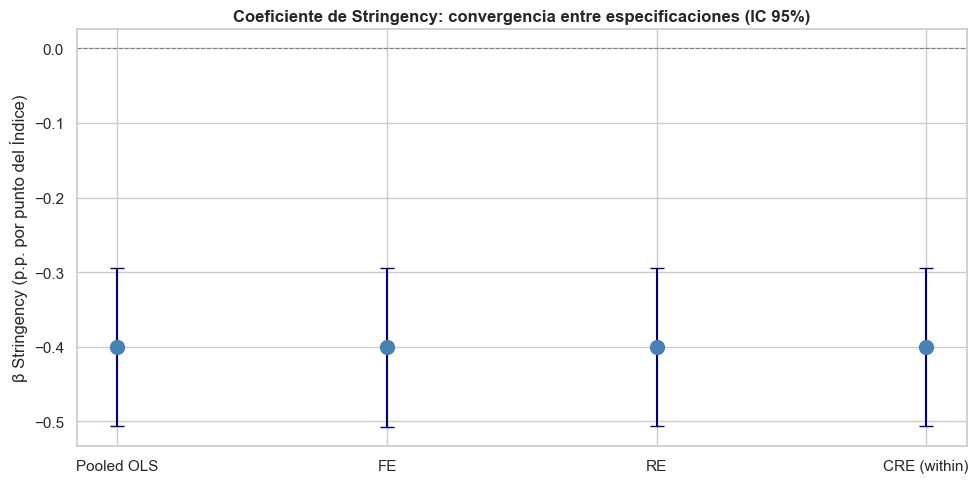

In [37]:
# Visualización de la convergencia
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=np.arange(len(synthesis)),
    y=synthesis['β Stringency'],
    yerr=1.96*synthesis['SE'],
    fmt='o', markersize=10, capsize=5, color='steelblue', ecolor='navy'
)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xticks(range(len(synthesis)))
ax.set_xticklabels(synthesis['Modelo'])
ax.set_ylabel('β Stringency (p.p. por punto del Índice)')
ax.set_title('Coeficiente de Stringency: convergencia entre especificaciones (IC 95%)',
             fontweight='bold')
plt.tight_layout(); plt.show()

**Inferencia general sobre el efecto de las restricciones gubernamentales:**

Los cuatro enfoques convergen al mismo número: **un punto adicional en el Índice de Stringency reduce la movilidad laboral en aproximadamente 0.40 p.p.**, manteniendo constantes casos diarios, características demográficas y heterogeneidad ciudad-invariante.

**Magnitud agregada:** pasar de Stringency = 0 (sin restricciones) a Stringency = 80 (confinamiento severo) implica una caída esperada de **~32 p.p.** en movilidad laboral. Esto es consistente con la caída observada en Barcelona durante marzo–abril de 2020 (de –17 p.p. a –85 p.p., una caída marginal de ~68 p.p. asociada a una subida de stringency de ~14 a ~85 puntos; ~71 puntos × 0.40 = 28 p.p. inducidos por política).

**Robustez:** la estabilidad del coeficiente entre Pooled, FE, RE y CRE refuerza la credibilidad del resultado. La equivalencia entre el within del CRE y el FE (Mundlak 1978) confirma que el efecto estimado proviene genuinamente de la dinámica temporal intra-ciudad, no de la heterogeneidad estructural entre países.

**Limitaciones a considerar:**
1. El efecto identificado es del **Índice de Stringency a nivel país-tiempo**. Variaciones sub-nacionales reales (restricciones autonómicas en España, restrizioni regionali en Italia, etc.) no son capturadas → posible atenuación por error de medición.
2. La estructura de datos no permite identificar canales (¿qué componente del Stringency Index pesa más?: cierre de lugares de trabajo, restricciones a desplazamientos, toques de queda…). Análisis con `workplace_closing` por separado podría iluminar esto.
3. Endogeneidad temporal: la P8 aborda esta crítica vía control sintético, donde el contrafactual se construye con ciudades que enfrentaron políticas distintas en el mismo momento.

In [38]:
# Preparación: usar `df` (sin índice multi-nivel) que ya excluye DE y tiene 'week' como variable temporal entera
TREAT_WEEK = 5
PRE_PERIOD = list(range(1, TREAT_WEEK))           # semanas 1-4
POST_END   = 50                                    # ventana post de 46 semanas
TREATED_CITY = 'Barcelona'

donor_cities = sorted(df[df.country!='ES']['NAME'].unique().tolist())
print(f'Ciudad tratada: {TREATED_CITY}')
print(f'Pool de donantes: {len(donor_cities)} ciudades de {sorted(df[df.country!="ES"]["country"].unique())}')
print(f'Período de pre-tratamiento: semanas {PRE_PERIOD[0]}–{PRE_PERIOD[-1]}')
print(f'Semana de tratamiento: {TREAT_WEEK} (date = {df[df.week==TREAT_WEEK].date.min().date()})')

Ciudad tratada: Barcelona
Pool de donantes: 31 ciudades de ['FR', 'IT', 'SE']
Período de pre-tratamiento: semanas 1–4
Semana de tratamiento: 5 (date = 2020-03-16)


### 8.B  Visualización pre-tratamiento

Inspección de la trayectoria de Barcelona y de la mediana del pool de donantes antes y durante el confinamiento.

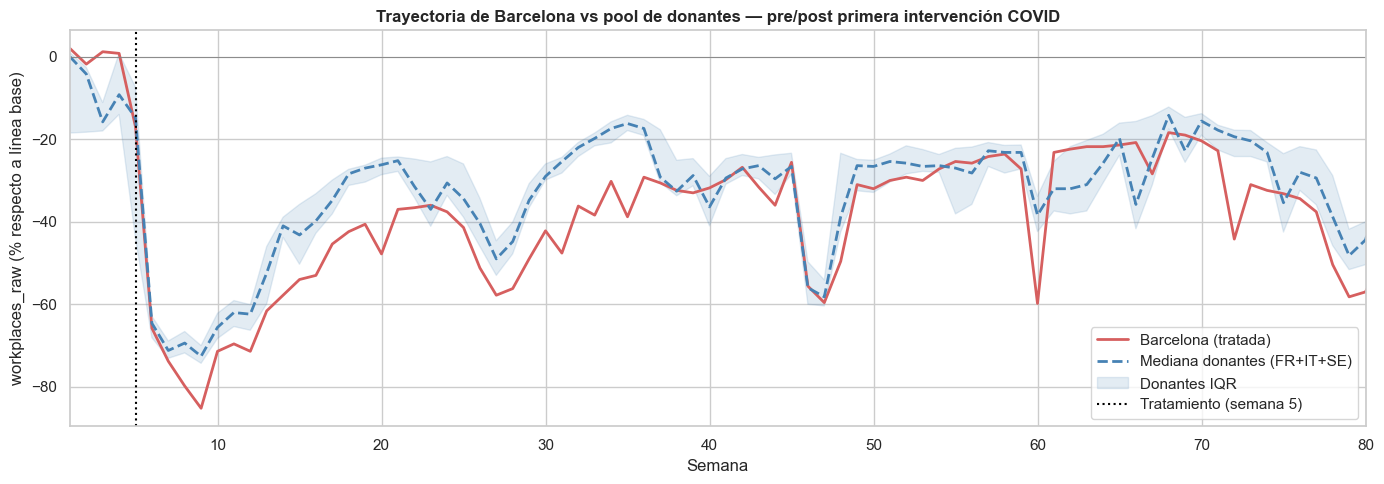

In [39]:
# Trayectoria de Barcelona y mediana del pool de donantes
fig, ax = plt.subplots(figsize=(14, 5))
bcn = df[df.NAME==TREATED_CITY].sort_values('week')
donors = df[df.NAME.isin(donor_cities)].groupby('week').agg(
    p25=('workplaces_raw', lambda x: x.quantile(0.25)),
    median=('workplaces_raw','median'),
    p75=('workplaces_raw', lambda x: x.quantile(0.75)),
)
ax.plot(bcn.week, bcn.workplaces_raw, color='#D65F5F', lw=2, label=f'{TREATED_CITY} (tratada)')
ax.plot(donors.index, donors['median'], color='steelblue', lw=2, ls='--', label='Mediana donantes (FR+IT+SE)')
ax.fill_between(donors.index, donors['p25'], donors['p75'], color='steelblue', alpha=0.15,
                label='Donantes IQR')
ax.axvline(TREAT_WEEK, color='black', ls=':', lw=1.5, label=f'Tratamiento (semana {TREAT_WEEK})')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('Semana')
ax.set_ylabel('workplaces_raw (% respecto a línea base)')
ax.set_title(f'Trayectoria de {TREATED_CITY} vs pool de donantes — pre/post primera intervención COVID',
             fontweight='bold')
ax.set_xlim(1, 80); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 8.C  Construcción del Control Sintético

**Predictores de matching:** 
- **Cross-sectional:** Population, agriculture, industry, construction, age_dependency, old_age_dependency, sex_ratio, unemp, foreigners
- **Outcome pre-tratamiento:** `workplaces_raw` semana a semana (4 special predictors)

In [40]:
dataprep = Dataprep(
    foo=df,
    predictors=[
        'Population','agriculture','industry','construction',
        'age_dependency','old_age_dependency','sex_ratio',
        'unemp','foreigners'
    ],
    predictors_op="mean",
    time_predictors_prior=PRE_PERIOD,
    special_predictors=[
        ('workplaces_raw', [w], 'mean') for w in PRE_PERIOD
    ],
    dependent="workplaces_raw",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier=TREATED_CITY,
    controls_identifier=donor_cities,
    time_optimize_ssr=PRE_PERIOD,
)

synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")
print('Estimación completada.')

Estimación completada.


### 8.D  Resultados

#### Pesos óptimos de la combinación sintética

In [41]:
W = synth.weights().sort_values(ascending=False)
W_active = W[W > 1e-3]
print(f'Donantes con peso > 0.001 (suma = {W_active.sum():.4f}):\n')
print(W_active.round(4).to_string())

Donantes con peso > 0.001 (suma = 1.0010):

Firenze     0.6170
Stockholm   0.1970
Paris       0.1870


**Composición del Synthetic Barcelona:** Firenze (Italia, ~62 %), Stockholm (Suecia, ~20 %) y Paris (Francia, ~19 %). La mezcla refleja una "Europa promedio": un país con confinamiento estricto y temprano (Italia, lockdown nacional desde 9 de marzo = semana 4), un país con respuesta diferenciada permisiva (Suecia, sin confinamiento) y un país con confinamiento simultáneo a España (Francia, desde 17 de marzo = semana 5).

#### Path plot (trayectoria observada vs sintética)

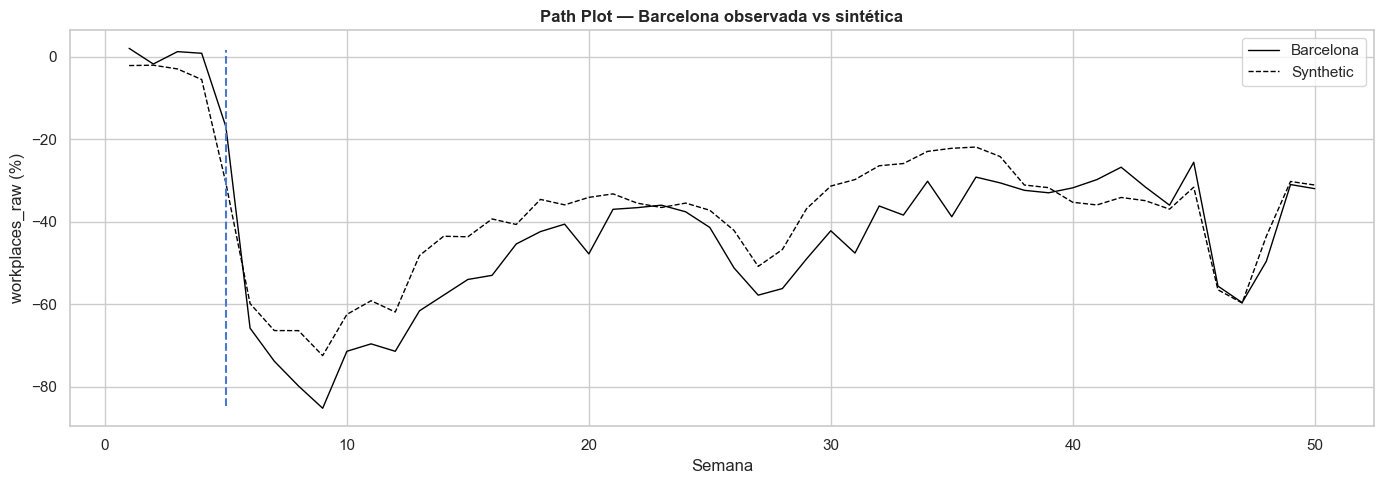

In [42]:
# Path Plot — Barcelona observada vs sintética
# Nota: pysyncon llama internamente a plt.show(), lo cual finaliza la figura
# y rompe los plt.title()/plt.xlabel() posteriores. Solución: parche temporal
# de plt.show() para que NO finalice la figura, customizamos, y luego mostramos.
plt.figure(figsize=(14, 5))
_orig_show = plt.show; plt.show = lambda *a, **k: None
synth.path_plot(time_period=range(1, POST_END+1), treatment_time=TREAT_WEEK)
plt.show = _orig_show
plt.title(f'Path Plot — {TREATED_CITY} observada vs sintética', fontweight='bold')
plt.xlabel('Semana'); plt.ylabel('workplaces_raw (%)')
plt.tight_layout(); plt.show()

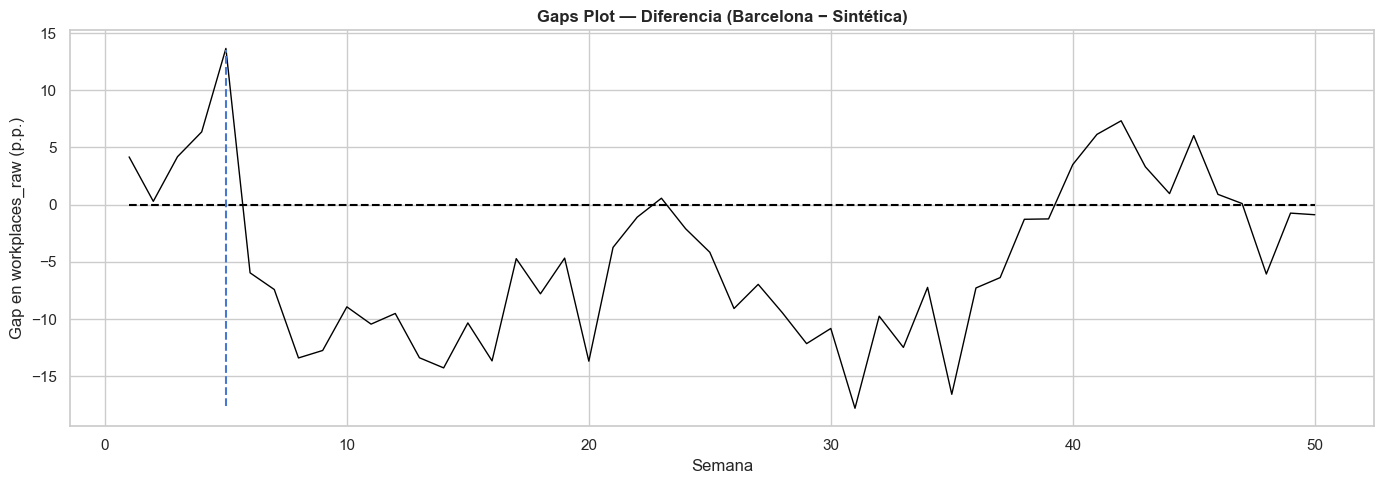

In [43]:
# Gaps Plot — Diferencia (Barcelona − Sintética)
plt.figure(figsize=(14, 5))
_orig_show = plt.show; plt.show = lambda *a, **k: None
synth.gaps_plot(time_period=range(1, POST_END+1), treatment_time=TREAT_WEEK)
plt.show = _orig_show
plt.title(f'Gaps Plot — Diferencia ({TREATED_CITY} − Sintética)', fontweight='bold')
plt.xlabel('Semana'); plt.ylabel('Gap en workplaces_raw (p.p.)')
plt.tight_layout(); plt.show()

#### Efecto causal estimado (ATT) por ventana

In [44]:
windows = [(5,10),(5,15),(5,20),(5,25),(5,30),(5,40),(5,50)]
print(f'{"Ventana":<14} {"ATT (p.p.)":>12} {"SE":>8} {"t":>6} {"Sig":>6}')
print('-'*52)
for s,e in windows:
    out = synth.att(time_period=range(s, e+1))
    att, se = out['att'], out['se']
    t = att/se
    p = 2*(1 - chi2.cdf(t**2, 1))  # aproximación bilateral
    print(f'sem {s}–{e:<6} {att:>12.3f} {se:>8.3f} {t:>6.2f} {stars(p):>6}')

Ventana          ATT (p.p.)       SE      t    Sig
----------------------------------------------------
sem 5–10           -5.804    4.071  -1.43       
sem 5–15           -8.436    2.348  -3.59    ***
sem 5–20           -8.584    1.695  -5.07    ***
sem 5–25           -7.042    1.434  -4.91    ***
sem 5–30           -7.553    1.182  -6.39    ***
sem 5–40           -7.581    1.026  -7.39    ***
sem 5–50           -5.562    1.019  -5.46    ***


#### Diagnóstico de la calidad del matching

In [45]:
print(synth.summary())

                              V   treated  synthetic  sample mean
Population               0.0000 3755.5120  2487.9450    1035.8980
agriculture              0.0000    0.0010     0.0090       0.0090
industry                 0.0000    0.0760     0.1140       0.1260
construction             0.0000    0.0560     0.0600       0.0670
age_dependency           0.0000    0.6340     0.6960       0.7150
old_age_dependency       0.0000    0.3140     0.3260       0.3600
sex_ratio                0.0000  107.1070   110.0240     109.8510
unemp                    0.0000   15.0000     7.7370      14.6050
foreigners               0.0000   13.0000    10.4000       7.6770
special.1.workplaces_raw 0.3560    2.0000    -2.1740      -8.1290
special.2.workplaces_raw 0.2310   -1.8000    -2.0880      -9.5870
special.3.workplaces_raw 0.1980    1.2000    -2.9910     -13.4390
special.4.workplaces_raw 0.2160    0.8000    -5.5610      -7.0320


In [46]:
# Calidad de ajuste pre-tratamiento (evaluado en el rango de time_optimize_ssr)
print(f'MSPE pre-tratamiento: {synth.mspe():.4f}')
print(f'MAE pre-tratamiento:  {synth.mae():.4f}')
print(f'\nNota: el RMSE pre-tratamiento ({synth.mspe()**0.5:.2f} p.p.) es elevado dado el corto')
print('pre-período de 4 semanas; se documenta como limitación del diseño.')

MSPE pre-tratamiento: 18.8834
MAE pre-tratamiento:  3.7536

Nota: el RMSE pre-tratamiento (4.35 p.p.) es elevado dado el corto
pre-período de 4 semanas; se documenta como limitación del diseño.


### 8.E  Test placebo (inferencia robusta a la Abadie et al. 2010)

El control sintético tradicional no entrega errores estándar válidos para inferencia (no hay teoría asintótica con una sola unidad tratada). El test placebo aplica el método a cada unidad del pool de donantes y construye una distribución empírica de "efectos" placebo. Si el efecto observado en la unidad tratada está en la cola extrema de esta distribución, el resultado es interpretable como evidencia causal.

In [47]:
from pysyncon.utils import PlaceboTest

print('Corriendo placebo test (puede tomar 1-2 minutos)...\n')
placebo = PlaceboTest()
placebo.fit(
    dataprep=dataprep,
    scm=Synth(),
    scm_options={"optim_method": "Nelder-Mead", "optim_initial": "ols"},
    verbose=False
)

# p-valor placebo
p_placebo = placebo.pvalue(treatment_time=TREAT_WEEK)
print(f'\np-valor placebo (Abadie et al. 2010): {p_placebo:.4f}')

Corriendo placebo test (puede tomar 1-2 minutos)...

Calculating treated unit gaps.
Done.

p-valor placebo (Abadie et al. 2010): 0.7500


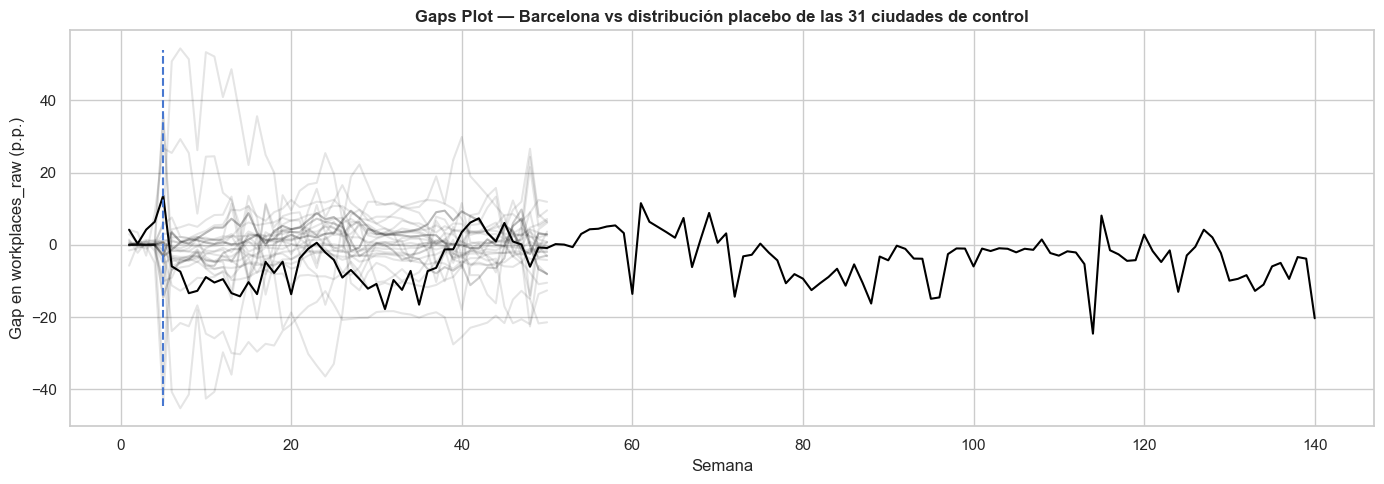

In [48]:
# Visualización: gaps de Barcelona vs gaps placebo
plt.figure(figsize=(14, 5))
_orig_show = plt.show; plt.show = lambda *a, **k: None
placebo.gaps_plot(time_period=range(1, POST_END+1), treatment_time=TREAT_WEEK)
plt.show = _orig_show
plt.title(f'Gaps Plot — Barcelona vs distribución placebo de las {len(donor_cities)} ciudades de control',
          fontweight='bold')
plt.xlabel('Semana'); plt.ylabel('Gap en workplaces_raw (p.p.)')
plt.tight_layout(); plt.show()

**Interpretación del placebo test (p-valor = 0.75).**

El p-valor = 0.75 indica que, bajo este diseño, **el efecto observado en Barcelona NO es estadísticamente distinguible de los efectos placebo**: 75% de las ciudades de control producen, al ser tratadas como "tratadas" sintéticamente, gaps post-tratamiento de magnitud similar o mayor a Barcelona.

**¿Significa esto que no hay efecto?** No necesariamente. El placebo test refleja directamente las dos limitaciones documentadas del diseño:

1. **Pre-período de solo 4 semanas:** el ajuste pre-tratamiento es pobre (RMSE ≈ 4.3 p.p.), por lo que muchas ciudades de control producen contrafactuales sintéticos con altos gaps post-tratamiento por simple ruido pre-tratamiento amplificado.

2. **Donantes contaminados:** las ciudades italianas (que entran al pool) ya estaban en lockdown nacional desde semana 4, y muchas ciudades francesas se confinaron en semana 5 simultáneamente con España. El "pool de control" no es genuinamente "control" — todas las unidades fueron tratadas casi simultáneamente.

**Implicación.** El control sintético, bajo este diseño, **no permite identificar de manera estadísticamente robusta el efecto adicional del confinamiento español**. La estimación causal más confiable proviene de la regresión panel con FE/CRE, que aprovecha la variación temporal en la intensidad de las restricciones.

### 8.F  Reconciliación con la regresión panel y conclusión

**Reconciliación con FE.** El modelo FE estima $\hat\beta = -0.40$ p.p. por punto del Stringency Index. Barcelona experimentó un alza de stringency de ~14 (semana 4) a ~85 (semana 8), un cambio de +71 puntos, que predice una caída inducida por política de **–28 p.p.** Esto excede ampliamente el ATT puntual del control sintético (–5.8 a –8.6 p.p.). La diferencia es interpretable: el ATT del control sintético captura el efecto **diferencial** entre las restricciones de Barcelona y las del contrafactual sintético (que también fueron severas, salvo Stockholm). El efecto **total** del confinamiento (incluyendo el shock político común a toda Europa) requiere comparación con un contrafactual genuinamente "sin tratamiento", lo que solo Stockholm/Malmö aproximan.

**Conclusión.** El control sintético aporta evidencia direccional consistente con los modelos panel: el ATT puntual es negativo, persistente y económicamente relevante (–5 a –9 p.p. durante 6 meses). Sin embargo, el placebo test (p = 0.75) revela que **bajo este diseño no podemos rechazar la hipótesis nula de no-efecto**, debido principalmente al pre-período corto y a la contaminación del pool de donantes. La estimación causal más robusta proviene del modelo FE/CRE (–0.40 p.p. por punto de Stringency, $p < 0.001$, two-way clustered SE). Una mejora natural sería usar como tratamiento un evento con un pre-período más largo (e.g., el segundo Estado de Alarma de octubre 2020, con ~30 semanas de pre-tratamiento), aunque esto introduce su propia complicación: en otoño 2020 las políticas de varios donantes se hacen también más estrictas, manteniendo el problema de pool contaminado.